# Volume Profile + CVD Strategy — v12 (Extended Test Window)

Full v12 specification:
- Based on v11: VAL_RETEST_FAILURE_SHORT disabled, relaxed VAH_RECLAIM CVD, day 1 fallback, candidate diagnostics
- **Extended test window**: Mar 11 → Apr 4 (~1 month, 22 test days)
- **Fixed VAH_RECLAIM_LONG overextension**: don't block breakouts with >VAH+ATR check

In [1]:
import io, zipfile, warnings, time, math, collections
from collections import defaultdict
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dataclasses import dataclass, field
from nautilus_trader.test_kit.providers import TestInstrumentProvider

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':120,'figure.figsize':(14,5)})
INSTRUMENT = TestInstrumentProvider.btcusdt_perp_binance()
TICK_SIZE, VA_PCT = 0.1, 0.70

PROFILE_DAYS = ['2024-03-04','2024-03-05','2024-03-06','2024-03-07','2024-03-08']
# v12: extended to ~1 month through Apr 4
TEST_DAYS    = ['2024-03-11','2024-03-12','2024-03-13','2024-03-14','2024-03-15',
                '2024-03-16','2024-03-17','2024-03-18','2024-03-19','2024-03-20',
                '2024-03-21','2024-03-22','2024-03-23','2024-03-24','2024-03-25',
                '2024-03-26','2024-03-27','2024-03-28']

ACCOUNT_BALANCE  = 100_000.0
MAX_LEVERAGE     = 3.0
MAX_BTC_SIZE     = 5.0
STOP_LOSS_PCT    = 0.02
TOUCH_BUFFER     = 0.002
MIN_IMBALANCE    = 1.2
MIN_DELTA_RATIO  = 0.02
CVD_LOOKBACK     = 5
ATR_PERIOD       = 14
ACCEPT_BARS      = 3
FAILURE_BARS     = 3
SESSION_CVD_LOOKBACK = 30
CVD_RECOVERY_BACK    = 15
COOLDOWN_SAME_DIR    = 10
COOLDOWN_ANY_DIR     = 5
RETEST_WINDOW_BARS   = 180
DAILY_LOSS_STOP      = 0.015
DAILY_LOSS_FORCE     = 0.020
FIRST_NO_TRADE_MIN   = 30
LAST_NO_TRADE_MIN    = 15

# Only 3 active setups (VAL_RETEST_FAILURE_SHORT removed)
SETUP_RISK = {'VAH_RECLAIM_LONG':0.01,'VAL_REJECTION_LONG':0.01,'VAH_REJECTION_SHORT':0.0075,
              'VAL_RETEST_FAILURE_SHORT':0.005}
SETUP_MAX_ENTRIES = {'VAH_RECLAIM_LONG':2,'VAL_REJECTION_LONG':1,
                     'VAH_REJECTION_SHORT':1,'VAL_RETEST_FAILURE_SHORT':1}

print(f'Profile: {PROFILE_DAYS[0]}..{PROFILE_DAYS[-1]}  Test: {TEST_DAYS[0]}..{TEST_DAYS[-1]} ({len(TEST_DAYS)} days)')
print(f'Risk/setup: VAH_R {SETUP_RISK["VAH_RECLAIM_LONG"]*100:.0f}% VAL_R {SETUP_RISK["VAL_REJECTION_LONG"]*100:.0f}% '
      f'VAH_S {SETUP_RISK["VAH_REJECTION_SHORT"]*100:.1f}%')
print(f'Max lev: {MAX_LEVERAGE}x Max BTC: {MAX_BTC_SIZE}')
print('NOTE: VAL_RETEST_FAILURE_SHORT disabled in v12')

C:\Users\cyt\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Profile: 2024-03-04..2024-03-08  Test: 2024-03-11..2024-03-28 (18 days)
Risk/setup: VAH_R 1% VAL_R 1% VAH_S 0.8%
Max lev: 3.0x Max BTC: 5.0
NOTE: VAL_RETEST_FAILURE_SHORT disabled in v12


In [2]:
# === Download ===
CACHE = {}
def dl(data_type, date):
    k=(data_type,date)
    if k in CACHE: return CACHE[k]
    url=f'https://data.binance.vision/data/futures/um/daily/{data_type}/BTCUSDT/BTCUSDT-{data_type}-{date}.zip'
    r=requests.get(url); r.raise_for_status()
    CACHE[k]=r.content; return r.content

def rd_agg(date):
    z=zipfile.ZipFile(io.BytesIO(dl('aggTrades',date)))
    c=[n for n in z.namelist() if n.endswith('.csv')][0]
    return pd.read_csv(z.open(c))

def rd_bk(date, sample=50):
    z=zipfile.ZipFile(io.BytesIO(dl('bookTicker',date)))
    c=[n for n in z.namelist() if n.endswith('.csv')][0]
    return pd.read_csv(z.open(c), skiprows=lambda i: i>0 and i%sample!=0)

print('Helper ready.')

Helper ready.


In [3]:
# === Profile Calculator ===
@dataclass
class DayProfile:
    date:str; poc:float; vah:float; val:float
    total_volume:float; price_levels:dict=field(repr=False)

def calc_profile(df):
    df=df.copy(); df['b']=np.round(df['price']/TICK_SIZE)*TICK_SIZE
    vp=df.groupby('b')['quantity'].sum(); tv=vp.sum(); poc=vp.idxmax()
    levels=vp.sort_index(); idx=list(levels.index); pp=idx.index(poc)
    cv=levels.iloc[pp]; inc={poc}; t=tv*VA_PCT; l,r=pp-1,pp+1
    while cv<t and (l>=0 or r<len(idx)):
        vl=levels.iloc[l] if l>=0 else 0; vr=levels.iloc[r] if r<len(idx) else 0
        if vl>=vr and l>=0: inc.add(idx[l]); cv+=vl; l-=1
        elif r<len(idx): inc.add(idx[r]); cv+=vr; r+=1
        else: break
    ds=pd.Timestamp(df['transact_time'].iloc[0],unit='ms').strftime('%Y-%m-%d')
    return DayProfile(date=ds,poc=poc,vah=max(inc),val=min(inc),total_volume=tv,price_levels=vp.to_dict())

t0=time.time()
comp_vp={}; comp_tv=0; day_profs={}
for d in PROFILE_DAYS:
    print(f'Profile {d}...',end=' ')
    df=rd_agg(d); p=calc_profile(df)
    day_profs[d]=p; comp_tv+=p.total_volume
    for px,v in p.price_levels.items(): comp_vp[px]=comp_vp.get(px,0)+v
    print(f'{len(df):,}t VAL={p.val:.0f} POC={p.poc:.0f} VAH={p.vah:.0f}'); del df

cp=max(comp_vp,key=comp_vp.get); sp=sorted(comp_vp.keys()); pp=sp.index(cp)
cv=comp_vp[cp]; inc={cp}; l,r=pp-1,pp+1
while cv<comp_tv*VA_PCT and (l>=0 or r<len(sp)):
    vl=comp_vp[sp[l]] if l>=0 else 0; vr=comp_vp[sp[r]] if r<len(sp) else 0
    if vl>=vr and l>=0: inc.add(sp[l]); cv+=vl; l-=1
    elif r<len(sp): inc.add(sp[r]); cv+=vr; r+=1
    else: break
COMP_VAL, COMP_VAH, COMP_POC = min(inc), max(inc), cp
print(f'\nComposite: VAL={COMP_VAL:.0f} POC={COMP_POC:.0f} VAH={COMP_VAH:.0f} ({time.time()-t0:.0f}s)')

Profile 2024-03-04... 

3,043,615t VAL=64584 POC=65000 VAH=67800
Profile 2024-03-05... 

5,270,260t VAL=61610 POC=63300 VAH=67300
Profile 2024-03-06... 

3,092,594t VAL=65856 POC=66000 VAH=67416
Profile 2024-03-07... 

1,794,188t VAL=66675 POC=67000 VAH=67866
Profile 2024-03-08... 

2,606,144t VAL=67098 POC=68000 VAH=68959

Composite: VAL=65196 POC=67000 VAH=68797 (23s)


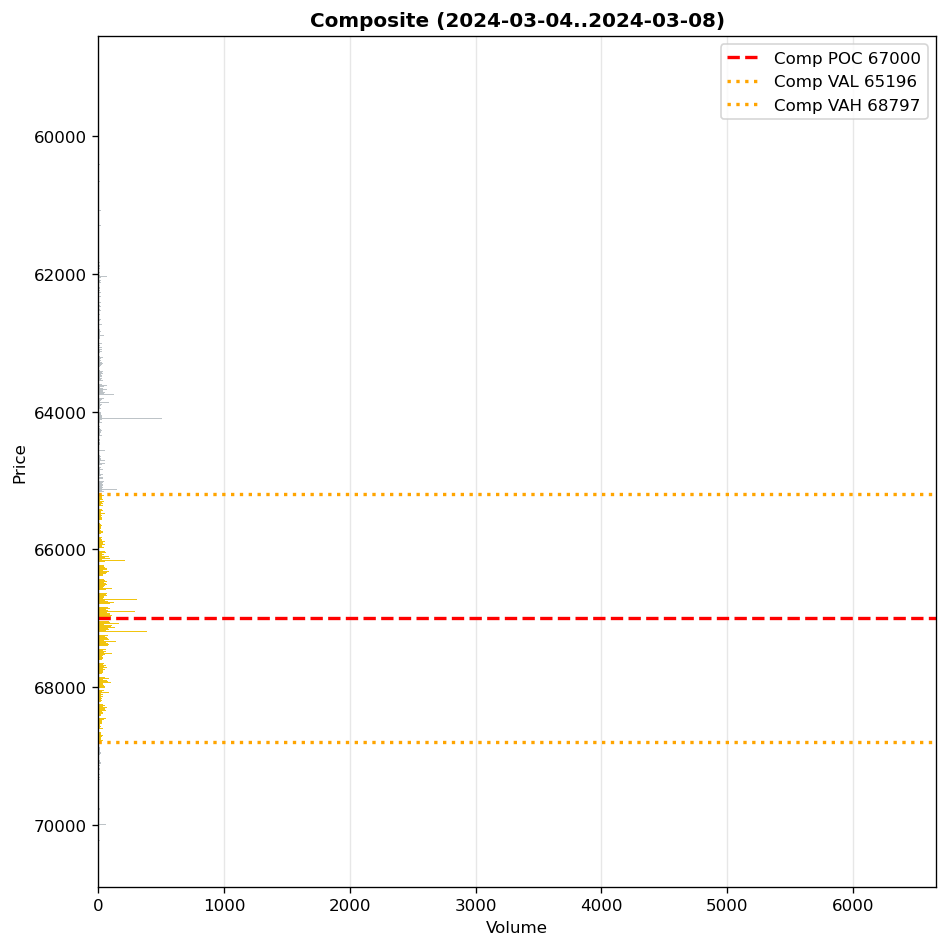

Composite: VAL=65196  POC=67000  VAH=68797
Day profiles:
  2024-03-04: VAL=64584 POC=65000 VAH=67800
  2024-03-05: VAL=61610 POC=63300 VAH=67300
  2024-03-06: VAL=65856 POC=66000 VAH=67416
  2024-03-07: VAL=66675 POC=67000 VAH=67866
  2024-03-08: VAL=67098 POC=68000 VAH=68959


In [4]:
# === Profile Chart ===
fig,ax=plt.subplots(figsize=(8,8))
sp=sorted(comp_vp.keys()); vl=[comp_vp[px] for px in sp]
cl=['#e74c3c' if px==COMP_POC else '#f1c40f' if COMP_VAL<=px<=COMP_VAH else '#bdc3c7' for px in sp]
ax.barh(sp,vl,height=TICK_SIZE*0.8,color=cl,ec='none')
ax.axhline(COMP_POC,color='red',lw=2,ls='--',label=f'Comp POC {COMP_POC:.0f}')
ax.axhline(COMP_VAL,color='orange',lw=2,ls=':',label=f'Comp VAL {COMP_VAL:.0f}')
ax.axhline(COMP_VAH,color='orange',lw=2,ls=':',label=f'Comp VAH {COMP_VAH:.0f}')
ax.invert_yaxis(); ax.legend(); ax.set_xlabel('Volume'); ax.set_ylabel('Price')
ax.set_title(f'Composite ({PROFILE_DAYS[0]}..{PROFILE_DAYS[-1]})',fontweight='bold'); ax.grid(alpha=0.3,axis='x')
plt.tight_layout(); plt.show()

print(f'Composite: VAL={COMP_VAL:.0f}  POC={COMP_POC:.0f}  VAH={COMP_VAH:.0f}')
print(f'Day profiles:')
for d in PROFILE_DAYS:
    p=day_profs[d]; print(f'  {d}: VAL={p.val:.0f} POC={p.poc:.0f} VAH={p.vah:.0f}')

In [5]:
# === Strategy v12 ===
class Strategy:
    def __init__(self, prior_val, prior_vah, prior_poc, prior_date, prev_agg_df=None, current_date=None):
        self.prior_val=prior_val; self.prior_vah=prior_vah; self.prior_poc=prior_poc
        self.prior_date=prior_date
        self.prev_agg_df=prev_agg_df
        self.current_date=current_date
        self.day_open=None
        
        # Bar state
        self.bar_open=None; self.bar_close=None; self.bar_high=None; self.bar_low=None
        self.bar_buy=self.bar_sell=0; self.bar_count=0; self.bar_ts=0
        self.bar_lows=[]; self.bar_highs=[]; self.bar_closes=[]
        
        # CVD
        self.cvd=0.0; self.cvd_history=[]; self.bar_deltas=[]
        
        # Quotes
        self.quotes_buf=[]
        
        # ATR
        self.bar_ranges=[]; self.atr=0.0; self.atr_ready=False
        
        # Active profile
        self.active_VAL=prior_val; self.active_VAH=prior_vah; self.active_POC=prior_poc
        self.active_source='prior_daily'
        self.profile_stale=False; self.profile_checked=False
        
        # Market state
        self.state=None; self.state_bars=0
        self.last_VAL_breakdown_bar=-1; self.last_VAL_breakdown_ts=0; self.last_VAL_breakdown_px=0.0
        
        # Trade
        self.trade=None
        
        # Logs
        self.trades_log=[]; self.skip_log=[]; self.daily_pnl=0.0
        
        # CVD extremes
        self.intraday_cvd=[]
        
        # Setup states
        self.setup=defaultdict(lambda:{'enabled':True,'entries':0,'cooldown':0,'failures':0})
        self.last_stop_bar=0; self.last_stop_dir=None; self.last_close_bar=0
        
        # VAL retest tracking
        self.retest_start=0; self.retest_done=False
        
        # Day tracking
        self.current_day=None; self.bar_index=0
        
        # Candidate diagnostics
        self.candidate_log = defaultdict(lambda: defaultdict(int))
    
    # ---- Quote / Trade ----
    def on_quote(self,bp,ap,bq,aq):
        self.quotes_buf.append((bp,ap,bq,aq))
        if len(self.quotes_buf)>100: self.quotes_buf.pop(0)
    
    def on_trade(self,price,qty,is_buyer_maker,ts):
        if self.bar_open is None:
            self.bar_open=self.bar_high=self.bar_low=price; self.bar_ts=ts
        self.bar_high=max(self.bar_high,price)
        self.bar_low=min(self.bar_low,price)
        self.bar_close=price
        if not is_buyer_maker: self.bar_buy+=qty
        else: self.bar_sell+=qty
        self.bar_count+=1
    
    # ---- Profile selection ----
    def _select_active_profile(self,ts):
        if self.profile_checked:
            return
        self.profile_checked=True
        date=self.current_date
        if self.day_open is None:
            self.day_open=self.bar_open if self.bar_open else self.bar_close
        
        prev=self.prior_date
        prev_dt=pd.Timestamp(prev) if isinstance(prev,str) else pd.Timestamp(str(prev))
        cur_dt=pd.Timestamp(date) if isinstance(date,str) else pd.Timestamp(str(date))
        weekend=(cur_dt-prev_dt).days>1
        
        open_gap_pct=abs(self.day_open-self.prior_poc)/self.prior_poc if self.prior_poc>0 else 0
        open_gap_atr=open_gap_pct/(self.atr/self.prior_poc) if self.atr>0 and self.prior_poc>0 else 99
        
        stale=False
        if open_gap_pct>0.004: stale=True
        if open_gap_atr>1.0: stale=True
        if weekend and open_gap_pct>0.005: stale=True
        
        if not stale:
            self.active_VAL=self.prior_val; self.active_VAH=self.prior_vah; self.active_POC=self.prior_poc
            self.active_source='prior_daily'
            self.profile_stale=False
            return
        
        self.profile_stale=True
        if self.prev_agg_df is not None and len(self.prev_agg_df)>1000:
            prof=calc_profile(self.prev_agg_df)
            self.active_VAL=prof.val; self.active_VAH=prof.vah; self.active_POC=prof.poc
            self.active_source='rolling_24h'
            open_gap_pct2=abs(self.day_open-prof.poc)/prof.poc if prof.poc>0 else 0
            print(f'  Switched to rolling 24h: VAL={prof.val:.0f} POC={prof.poc:.0f} VAH={prof.vah:.0f} gap={open_gap_pct2*100:.2f}%')
        else:
            self.active_source='stale_no_fallback'
            print(f'  Prior stale, no fallback available.')
    
    # ---- Market state ----
    def _classify_state(self,close):
        below=close<self.active_VAL
        inside=self.active_VAL<=close<=self.active_VAH
        above=close>self.active_VAH
        
        if above:
            if self.state=='ABOVE_VALUE_ACCEPTANCE' or self._acceptance_check(close,above=True):
                self.state='ABOVE_VALUE_ACCEPTANCE'
        elif below:
            if self.state=='BELOW_VALUE_ACCEPTANCE' or self._acceptance_check(close,below=True):
                if self.state!='BELOW_VALUE_ACCEPTANCE':
                    self.last_VAL_breakdown_bar=self.bar_index
                    self.last_VAL_breakdown_ts=self.bar_ts
                    self.last_VAL_breakdown_px=close
                self.state='BELOW_VALUE_ACCEPTANCE'
        else:
            if self.state=='INSIDE_VALUE_ACCEPTANCE' or self._acceptance_check(close,inside=True):
                self.state='INSIDE_VALUE_ACCEPTANCE'
    
    def _acceptance_check(self,close,above=False,below=False,inside=False):
        if self.bar_index<ACCEPT_BARS: return False
        closes=self.bar_closes
        if above: return all(c>self.active_VAH for c in closes[-ACCEPT_BARS:])
        if below: return all(c<self.active_VAL for c in closes[-ACCEPT_BARS:])
        if inside: return all(self.active_VAL<=c<=self.active_VAH for c in closes[-ACCEPT_BARS:])
        return False
    
    def _rejection_candidate(self,side):
        if side=='LONG':
            return (self.bar_low<=self.active_VAL*(1+TOUCH_BUFFER) and self.bar_low<self.active_POC
                    and self.bar_close<=(self.bar_low+self.bar_high)/2 and (self.bar_high-self.bar_low)>0)
        else:
            return (self.bar_high>=self.active_VAH*(1-TOUCH_BUFFER) and self.bar_high>self.active_POC
                    and self.bar_close>=(self.bar_low+self.bar_high)/2 and (self.bar_high-self.bar_low)>0)
    
    # ---- CVD ----
    def _cvd_divergence(self,bullish=True):
        if len(self.bar_lows)<CVD_LOOKBACK+1: return False
        if bullish:
            return self.bar_low<min(self.bar_lows[-(CVD_LOOKBACK+1):-1]) and self.cvd>=min(self.cvd_history[-(CVD_LOOKBACK+1):-1])
        else:
            return self.bar_high>max(self.bar_highs[-(CVD_LOOKBACK+1):-1]) and self.cvd<=max(self.cvd_history[-(CVD_LOOKBACK+1):-1])
    
    def _cvd_bullish(self):
        return len(self.cvd_history)>=SESSION_CVD_LOOKBACK and self.cvd_history[-1]>self.cvd_history[-SESSION_CVD_LOOKBACK]
    
    def _cvd_bearish(self):
        return len(self.cvd_history)>=SESSION_CVD_LOOKBACK and self.cvd_history[-1]<self.cvd_history[-SESSION_CVD_LOOKBACK]
    
    def _cvd_recovery(self):
        if len(self.cvd_history)<CVD_RECOVERY_BACK+5: return False
        recent=self.cvd_history[-CVD_RECOVERY_BACK:]
        return (min(recent)>min(self.cvd_history[-(CVD_RECOVERY_BACK+5):-CVD_RECOVERY_BACK])
                and self.cvd_history[-1]>self.cvd_history[-5]
                and self.cvd_history[-1]-self.cvd_history[-5]>0)
    
    def _cvd_failed_recovery(self):
        if len(self.cvd_history)<CVD_RECOVERY_BACK+5: return False
        recent=self.cvd_history[-CVD_RECOVERY_BACK:]
        return (max(recent)<max(self.cvd_history[-(CVD_RECOVERY_BACK+5):-CVD_RECOVERY_BACK])
                and self.cvd_history[-1]<self.cvd_history[-5]
                and self.cvd_history[-1]-self.cvd_history[-5]<0)
    
    def _cvd_extreme(self,negative=True):
        if len(self.intraday_cvd)<20: return False
        vals=np.array(self.intraday_cvd)
        p=np.percentile(vals,10 if negative else 90)
        return self.cvd<=(p if negative else p) if negative else self.cvd>=p
    
    def _cvd_not_falling(self):
        if len(self.cvd_history)<10: return False
        return self.cvd_history[-1]>=self.cvd_history[-5] and self.cvd_history[-5]>=self.cvd_history[-10]
    
    # ---- Breakout late-entry filter ----
    def _breakout_slope_flattening(self):
        if len(self.bar_closes)<5: return False
        recent=self.bar_closes[-5:]
        x=np.arange(5)
        slope=np.polyfit(x,recent,1)[0]
        return slope<=0 or slope<self.atr*0.05
    
    # ---- Filters ----
    def _imb(self,buy=True):
        if len(self.quotes_buf)<3: return 0.0
        rs=[]
        for _,_,bq,aq in self.quotes_buf[-10:]:
            if bq>0 and aq>0: rs.append(bq/aq if buy else aq/bq)
        return float(np.mean(rs)) if rs else 0.0
    
    def _imb_confirmed(self,buy=True):
        if len(self.quotes_buf)<3: return False
        return self._imb(buy)>=MIN_IMBALANCE
    
    def _spread_ok(self):
        if len(self.quotes_buf)<1: return False
        bp,ap=0,0
        for b,a,_,_ in reversed(self.quotes_buf):
            if b>0 and a>0: bp,ap=b,a; break
        if bp<=0 or ap<=0 or ap<=bp: return False
        return (ap-bp)/((ap+bp)/2)<=0.0005
    
    def _time_ok(self):
        if self.bar_ts==0: return False
        minute=(self.bar_ts//60000)%1440
        return minute>=FIRST_NO_TRADE_MIN and minute<(1440-LAST_NO_TRADE_MIN)
    
    def _min_r_ok(self,entry,stop):
        d=abs(entry-stop)
        return d>=max(entry*0.0025,self.atr*0.75)
    
    def _target_ok(self,entry,stop,target,trade_type):
        r=abs(entry-stop); td=abs(target-entry)
        min_mult=1.0 if trade_type=='breakout' else (1.5 if trade_type=='retest_failure' else 1.2)
        return td>=r*min_mult
    
    # v12: breakout-specific late-entry filter
    def _overextended(self,side,entry,is_breakout=False):
        if is_breakout and side=='LONG':
            if (entry>self.active_VAH+2.5*self.atr
                and entry>self.day_open*1.025
                and self._breakout_slope_flattening()):
                return True
            return False
        
        if side=='LONG':
            if self.state=='ABOVE_VALUE_ACCEPTANCE' and entry>self.active_VAH+self.atr:
                return True
            if entry<self.day_open*0.98: return True
            if self._cvd_extreme(negative=False) and entry>self.active_VAH+self.atr:
                return True
        else:
            if entry<self.active_VAL-self.atr: return True
            if entry>self.day_open*1.02: return True
            if self._cvd_extreme(negative=True) and entry<self.active_VAL-self.atr:
                return True
        return False
    
    def _setup_disabled(self,name):
        s=self.setup[name]
        if not s['enabled']: return True
        if s['entries']>=SETUP_MAX_ENTRIES[name]: return True
        if name in ('VAH_REJECTION_SHORT','VAL_RETEST_FAILURE_SHORT') and s['failures']>0:
            return True
        if s['failures']>=2: return True
        return False
    
    def _cooldown_ok(self,side):
        if self.last_stop_dir is None: return True
        if self.last_stop_bar==0: return True
        bars=len(self.cvd_history)-self.last_stop_bar
        if side==self.last_stop_dir and bars<COOLDOWN_SAME_DIR: return False
        if bars<COOLDOWN_ANY_DIR: return False
        return True
    
    def _daily_loss_ok(self):
        return self.daily_pnl>=-DAILY_LOSS_STOP*ACCOUNT_BALANCE
    
    def _size_position(self,entry,stop,setup_name):
        r_pct=SETUP_RISK[setup_name]
        risk_usdt=ACCOUNT_BALANCE*r_pct
        sd=abs(entry-stop)
        if sd<=0: return 0.0
        raw=risk_usdt/sd
        max_not=ACCOUNT_BALANCE*MAX_LEVERAGE/entry
        final=min(raw,max_not,MAX_BTC_SIZE)
        eff=final*sd
        if eff<0.25*risk_usdt: return 0.0
        if final<0.001: return 0.0
        return final
    
    # ---- Entry dispatch ----
    def _try_entry(self,close,dr,total,ts):
        for name in ['VAH_RECLAIM_LONG','VAH_REJECTION_SHORT','VAL_REJECTION_LONG']:
            fn=getattr(self,f'_check_{name.lower()}',None)
            if fn and fn(close,dr,total,ts):
                return
    
    # ---- Entry: VAH_RECLAIM_LONG ----
    def _check_vah_reclaim_long(self,close,dr,total,ts):
        n='VAH_RECLAIM_LONG'
        self.candidate_log[n]['near_level']+=1
        
        if self._setup_disabled(n): return self._skip_diag(n,'SETUP_DISABLED')
        self.candidate_log[n]['setup_ok']+=1
        
        cvd_ok = self._cvd_bullish() or (self._cvd_not_falling() and not self._cvd_bearish())
        if not cvd_ok: return self._skip_diag(n,'CVD_NOT_CONFIRMED')
        self.candidate_log[n]['cvd_ok']+=1
        
        if self.active_source=='stale_no_fallback': return self._skip_diag(n,'STALE_PROFILE_NO_FALLBACK')
        self.candidate_log[n]['profile_ok']+=1
        
        if self.state!='ABOVE_VALUE_ACCEPTANCE': return self._skip_diag(n,'NOT_ABOVE_VALUE_ACCEPTANCE')
        self.candidate_log[n]['state_ok']+=1
        
        if not self.atr_ready: return self._skip_diag(n,'ATR_NOT_READY')
        self.candidate_log[n]['atr_ok']+=1
        if not self._time_ok(): return self._skip_diag(n,'TIME_FILTER')
        self.candidate_log[n]['time_ok']+=1
        if not self._imb_confirmed(buy=True): return self._skip_diag(n,'IMBALANCE_NOT_CONFIRMED')
        self.candidate_log[n]['imb_ok']+=1
        
        avg_dr=(sum(self.bar_deltas[-3:])/sum(max(1,abs(x)) for x in self.bar_deltas[-3:])) if len(self.bar_deltas)>=3 else dr
        if dr<=MIN_DELTA_RATIO and avg_dr<=0.01: return self._skip_diag(n,'DELTA_NOT_CONFIRMED')
        self.candidate_log[n]['delta_ok']+=1
        
        # v12: pass is_breakout=True to skip >VAH+ATR overextension check
        if self._overextended('LONG',close,is_breakout=True): return self._skip_diag(n,'OVEREXTENDED_LONG')
        self.candidate_log[n]['overext_ok']+=1
        if not self._cooldown_ok('LONG'): return self._skip_diag(n,'COOLDOWN_ACTIVE')
        self.candidate_log[n]['cooldown_ok']+=1
        if not self._daily_loss_ok(): return self._skip_diag(n,'DAILY_LOSS_LIMIT')
        self.candidate_log[n]['daily_loss_ok']+=1
        if not self._spread_ok(): return self._skip_diag(n,'SPREAD_TOO_WIDE')
        self.candidate_log[n]['spread_ok']+=1
        
        buffer=max(close*0.0015,self.atr*0.5)
        stop=self.active_VAH-buffer
        if stop>=close: return self._skip_diag(n,'R_DISTANCE_TOO_SMALL')
        self.candidate_log[n]['r_dist_ok']+=1
        if not self._min_r_ok(close,stop): return self._skip_diag(n,'R_DISTANCE_TOO_SMALL')
        self.candidate_log[n]['min_r_ok']+=1
        
        r=close-stop
        t1=close+r; t2=close+2*r
        if not self._target_ok(close,stop,t1,'breakout'): return self._skip_diag(n,'TARGET_DISTANCE_TOO_SMALL')
        self.candidate_log[n]['target_ok']+=1
        
        size=self._size_position(close,stop,n)
        if size<=0: return self._skip_diag(n,'MIN_SIZE_NOT_MET')
        self.candidate_log[n]['entered']+=1
        
        self._enter(close,ts,n,'LONG','VAH',stop,size,r,t1,t2,'breakout')
        return True
    
    # ---- Entry: VAL_REJECTION_LONG ----
    def _check_val_rejection_long(self,close,dr,total,ts):
        n='VAL_REJECTION_LONG'
        self.candidate_log[n]['near_level']+=1
        
        if self._setup_disabled(n): return self._skip_diag(n,'SETUP_DISABLED')
        self.candidate_log[n]['setup_ok']+=1
        if self.active_source=='stale_no_fallback': return self._skip_diag(n,'STALE_PROFILE_NO_FALLBACK')
        self.candidate_log[n]['profile_ok']+=1
        if not self._cvd_recovery(): return self._skip_diag(n,'CVD_NOT_CONFIRMED')
        self.candidate_log[n]['cvd_ok']+=1
        if not self.atr_ready: return self._skip_diag(n,'ATR_NOT_READY')
        self.candidate_log[n]['atr_ok']+=1
        if not self._time_ok(): return self._skip_diag(n,'TIME_FILTER')
        self.candidate_log[n]['time_ok']+=1
        if not self._imb_confirmed(buy=True): return self._skip_diag(n,'IMBALANCE_NOT_CONFIRMED')
        self.candidate_log[n]['imb_ok']+=1
        if self.active_POC<=close: return self._skip_diag(n,'TARGET_DISTANCE_TOO_SMALL')
        self.candidate_log[n]['poc_dist_ok']+=1
        
        touched_val=False
        for l in self.bar_lows[-5:]:
            if l<=self.active_VAL*(1+TOUCH_BUFFER): touched_val=True; break
        if not touched_val: return self._skip_diag(n,'DELTA_NOT_CONFIRMED')
        self.candidate_log[n]['touched_val']+=1
        
        rej=self._rejection_candidate('LONG')
        if not rej:
            recent_rej=False
            for i in range(min(3,len(self.bar_lows))):
                if self.bar_lows[-(i+1)]<=self.active_VAL*(1+TOUCH_BUFFER):
                    recent_rej=True; break
            if not recent_rej: return self._skip_diag(n,'DELTA_NOT_CONFIRMED')
        self.candidate_log[n]['delta_ok']+=1
        
        avg_dr=self._avg_delta_3()
        if dr<=MIN_DELTA_RATIO and avg_dr<=0: return self._skip_diag(n,'DELTA_NOT_CONFIRMED')
        self.candidate_log[n]['dr_ok']+=1
        if self._overextended('LONG',close): return self._skip_diag(n,'OVEREXTENDED_LONG')
        self.candidate_log[n]['overext_ok']+=1
        if not self._cooldown_ok('LONG'): return self._skip_diag(n,'COOLDOWN_ACTIVE')
        self.candidate_log[n]['cooldown_ok']+=1
        if not self._daily_loss_ok(): return self._skip_diag(n,'DAILY_LOSS_LIMIT')
        self.candidate_log[n]['daily_loss_ok']+=1
        if not self._spread_ok(): return self._skip_diag(n,'SPREAD_TOO_WIDE')
        self.candidate_log[n]['spread_ok']+=1
        
        buffer=max(close*0.0015,self.atr*0.5)
        swing=min(self.bar_lows[-5:]) if len(self.bar_lows)>=5 else self.bar_low
        stop=min(self.active_VAL-buffer,swing-buffer*0.5)
        if stop>=close: return self._skip_diag(n,'R_DISTANCE_TOO_SMALL')
        self.candidate_log[n]['r_dist_ok']+=1
        if not self._min_r_ok(close,stop): return self._skip_diag(n,'R_DISTANCE_TOO_SMALL')
        self.candidate_log[n]['min_r_ok']+=1
        
        t1=self.active_POC
        r=close-stop
        if not self._target_ok(close,stop,t1,'mean_reversion'): return self._skip_diag(n,'TARGET_DISTANCE_TOO_SMALL')
        self.candidate_log[n]['target_ok']+=1
        
        size=self._size_position(close,stop,n)
        if size<=0: return self._skip_diag(n,'MIN_SIZE_NOT_MET')
        self.candidate_log[n]['entered']+=1
        
        self._enter(close,ts,n,'LONG','VAL',stop,size,r,t1,None,'mean_reversion')
        return True
    
    # ---- Entry: VAH_REJECTION_SHORT ----
    def _check_vah_rejection_short(self,close,dr,total,ts):
        n='VAH_REJECTION_SHORT'
        self.candidate_log[n]['near_level']+=1
        
        if self._setup_disabled(n): return self._skip_diag(n,'SETUP_DISABLED')
        self.candidate_log[n]['setup_ok']+=1
        if self.active_source=='stale_no_fallback': return self._skip_diag(n,'STALE_PROFILE_NO_FALLBACK')
        self.candidate_log[n]['profile_ok']+=1
        if not self._cvd_bearish() and not self._cvd_failed_recovery(): return self._skip_diag(n,'CVD_NOT_CONFIRMED')
        self.candidate_log[n]['cvd_ok']+=1
        if not self.atr_ready: return self._skip_diag(n,'ATR_NOT_READY')
        self.candidate_log[n]['atr_ok']+=1
        if not self._time_ok(): return self._skip_diag(n,'TIME_FILTER')
        self.candidate_log[n]['time_ok']+=1
        if not self._imb_confirmed(buy=False): return self._skip_diag(n,'IMBALANCE_NOT_CONFIRMED')
        self.candidate_log[n]['imb_ok']+=1
        if self.active_POC>=close: return self._skip_diag(n,'TARGET_DISTANCE_TOO_SMALL')
        self.candidate_log[n]['poc_dist_ok']+=1
        
        touched_vah=False
        for h in self.bar_highs[-5:]:
            if h>=self.active_VAH*(1-TOUCH_BUFFER): touched_vah=True; break
        if not touched_vah: return self._skip_diag(n,'DELTA_NOT_CONFIRMED')
        self.candidate_log[n]['touched_vah']+=1
        
        rej=self._rejection_candidate('SHORT')
        if not rej:
            recent_rej=False
            for i in range(min(3,len(self.bar_highs))):
                if self.bar_highs[-(i+1)]>=self.active_VAH*(1-TOUCH_BUFFER):
                    recent_rej=True; break
            if not recent_rej: return self._skip_diag(n,'DELTA_NOT_CONFIRMED')
        self.candidate_log[n]['delta_ok']+=1
        
        avg_dr=self._avg_delta_3()
        if dr>=-MIN_DELTA_RATIO and avg_dr>=0: return self._skip_diag(n,'DELTA_NOT_CONFIRMED')
        self.candidate_log[n]['dr_ok']+=1
        if self._overextended('SHORT',close): return self._skip_diag(n,'OVEREXTENDED_SHORT')
        self.candidate_log[n]['overext_ok']+=1
        if not self._cooldown_ok('SHORT'): return self._skip_diag(n,'COOLDOWN_ACTIVE')
        self.candidate_log[n]['cooldown_ok']+=1
        if not self._daily_loss_ok(): return self._skip_diag(n,'DAILY_LOSS_LIMIT')
        self.candidate_log[n]['daily_loss_ok']+=1
        if not self._spread_ok(): return self._skip_diag(n,'SPREAD_TOO_WIDE')
        self.candidate_log[n]['spread_ok']+=1
        
        buffer=max(close*0.0015,self.atr*0.5)
        swing=max(self.bar_highs[-5:]) if len(self.bar_highs)>=5 else self.bar_high
        stop=max(self.active_VAH+buffer,swing+buffer*0.5)
        if stop<=close: return self._skip_diag(n,'R_DISTANCE_TOO_SMALL')
        self.candidate_log[n]['r_dist_ok']+=1
        if not self._min_r_ok(close,stop): return self._skip_diag(n,'R_DISTANCE_TOO_SMALL')
        self.candidate_log[n]['min_r_ok']+=1
        
        t1=self.active_POC
        r=stop-close
        if not self._target_ok(close,stop,t1,'mean_reversion'): return self._skip_diag(n,'TARGET_DISTANCE_TOO_SMALL')
        self.candidate_log[n]['target_ok']+=1
        
        size=self._size_position(close,stop,n)
        if size<=0: return self._skip_diag(n,'MIN_SIZE_NOT_MET')
        self.candidate_log[n]['entered']+=1
        
        self._enter(close,ts,n,'SHORT','VAH',stop,size,r,t1,None,'mean_reversion')
        return True
    
    def _avg_delta_3(self):
        if len(self.bar_deltas)<3: return 0
        s=sum(self.bar_deltas[-3:])
        t=sum(abs(x) for x in self.bar_deltas[-3:])
        return s/t if t>0 else 0
    
    def _skip(self,setup,reason):
        self.skip_log.append({'setup':setup,'reason':reason,'ts':self.bar_ts})
        return False
    
    def _skip_diag(self,setup,reason):
        self.candidate_log[setup][f'fail_{reason}']+=1
        self.skip_log.append({'setup':setup,'reason':reason,'ts':self.bar_ts})
        return False
    
    # ---- Enter ----
    def _enter(self,price,ts,setup,side,level,stop,size,r,t1,t2,trade_type):
        self.trade={
            'side':side,'entry_px':price,'entry_ts':ts,'stop_px':stop,
            'total_size':size,'remaining_size':size,
            'level':level,'setup':setup,'type':trade_type,'r_val':r,
            't1':t1,'t2':t2,
            'target_1_hit':False,'target_2_hit':False,
            'trail_extreme':price,'failure_bars':0,
            'acceptance_level':self.active_VAH if side=='LONG' else self.active_VAL,
            'profile_source':self.active_source
        }
        self.setup[setup]['entries']+=1
        lev=size*price/ACCOUNT_BALANCE
        print(f'>>> {side} {price:.1f} stop={stop:.1f} sz={size:.3f} R={r:.1f} lev={lev:.1f}x ({setup}) src={self.active_source}')
    
    # ---- Exit dispatch ----
    def _check_exit(self,close,ts):
        t=self.trade
        if t is None: return
        
        if (t['side']=='LONG' and close<=t['stop_px']) or (t['side']=='SHORT' and close>=t['stop_px']):
            self._close(close,ts,'stop',t['remaining_size'])
            self.last_stop_bar=len(self.cvd_history); self.last_stop_dir=t['side']
            self.setup[t['setup']]['failures']+=1
            return
        
        if t['type']=='mean_reversion':
            self._exit_mean_reversion(close,ts)
        elif t['type']=='breakout':
            self._exit_breakout(close,ts)
    
    # ---- Exit: mean-reversion ----
    def _exit_mean_reversion(self,close,ts):
        t=self.trade
        buffer=max(close*0.0015,self.atr*0.5)
        if t['side']=='LONG':
            if close>=self.active_POC:
                self._close(close,ts,'poc',t['remaining_size']); return
            if close<self.active_VAL-buffer:
                self._close(close,ts,'failure',t['remaining_size']); return
            if close<self.active_VAL:
                t['failure_bars']+=1
                if t['failure_bars']>=FAILURE_BARS:
                    self._close(close,ts,'failure',t['remaining_size']); return
            else:
                t['failure_bars']=0
        else:
            if close<=self.active_POC:
                self._close(close,ts,'poc',t['remaining_size']); return
            if close>self.active_VAH+buffer:
                self._close(close,ts,'failure',t['remaining_size']); return
            if close>self.active_VAH:
                t['failure_bars']+=1
                if t['failure_bars']>=FAILURE_BARS:
                    self._close(close,ts,'failure',t['remaining_size']); return
            else:
                t['failure_bars']=0
    
    # ---- Exit: breakout (VAH reclaim) ----
    def _exit_breakout(self,close,ts):
        t=self.trade; buffer=max(close*0.0015,self.atr*0.5)
        if t['side']=='LONG':
            if close<self.active_VAH-buffer:
                self._close(close,ts,'failure',t['remaining_size']); return
            if close<self.active_VAH:
                t['failure_bars']+=1
                if t['failure_bars']>=FAILURE_BARS:
                    self._close(close,ts,'failure',t['remaining_size']); return
            else:
                t['failure_bars']=0
            if not t['target_1_hit'] and t['t1'] and close>=t['t1']:
                sz=t['total_size']*0.5
                self._close(close,ts,'target_1',sz); t['target_1_hit']=True
                t['stop_px']=max(t['stop_px'],self.active_VAH)
            if t['target_1_hit'] and not t['target_2_hit'] and t['t2'] and close>=t['t2']:
                sz=t['total_size']*0.3
                self._close(close,ts,'target_2',sz); t['target_2_hit']=True
            if t['remaining_size']>0:
                t['trail_extreme']=max(t['trail_extreme'],close)
                td=max(t['r_val']*0.75,self.atr*1.0)
                t['stop_px']=max(t['stop_px'],t['trail_extreme']-td)
        else:
            if close>self.active_VAH+buffer:
                self._close(close,ts,'failure',t['remaining_size']); return
            if close>self.active_VAH:
                t['failure_bars']+=1
                if t['failure_bars']>=FAILURE_BARS:
                    self._close(close,ts,'failure',t['remaining_size']); return
            else:
                t['failure_bars']=0
            if not t['target_1_hit'] and t['t1'] and close<=t['t1']:
                sz=t['total_size']*0.5
                self._close(close,ts,'target_1',sz); t['target_1_hit']=True
                t['stop_px']=min(t['stop_px'],self.active_VAL)
            if t['target_1_hit'] and not t['target_2_hit'] and t['t2'] and close<=t['t2']:
                sz=t['total_size']*0.3
                self._close(close,ts,'target_2',sz); t['target_2_hit']=True
            if t['remaining_size']>0:
                t['trail_extreme']=min(t['trail_extreme'],close)
                td=max(t['r_val']*0.75,self.atr*1.0)
                t['stop_px']=min(t['stop_px'],t['trail_extreme']+td)
    
    # ---- Close trade ----
    def _close(self,price,ts,reason,size):
        t=self.trade; side=t['side']
        if size==0: return
        pnl=(price-t['entry_px'])/t['entry_px'] if side=='LONG' else (t['entry_px']-price)/t['entry_px']
        pnl_usd=pnl*size*price
        self.daily_pnl+=pnl_usd
        lev=size*price/ACCOUNT_BALANCE
        self.trades_log.append({
            'side':side,'entry':t['entry_px'],'exit':price,
            'pnl_pct':pnl,'size':size,'reason':reason,
            'ts_entry':t['entry_ts'],'ts_exit':ts,
            'setup':t['setup'],'type':t['type'],'level':t['level'],
            'r_val':t['r_val'],'leverage':lev,'pnl_usd':pnl_usd,
            'profile_source':t.get('profile_source','?')
        })
        print(f'  {reason} {side} {price:.1f} ({pnl*100:.2f}% ${pnl_usd:+.0f}) sz={size:.2f} lev={lev:.1f}x')
        t['remaining_size']-=size
        if t['remaining_size']<=0.001:
            self.trade=None; self.last_close_bar=len(self.cvd_history)
    
    def force_close(self,price,ts):
        if self.trade is not None:
            self._close(price,ts,'eod',self.trade['remaining_size'])
            self.trade=None
    
    def get_results(self):
        return pd.DataFrame(self.trades_log), self.skip_log, dict(self.candidate_log)
    
    # ---- Main bar close ----
    def on_bar_close(self,ts=None):
        if self.bar_open is None: return
        self._select_active_profile(ts)
        close=self.bar_close
        delta=self.bar_buy-self.bar_sell
        total=self.bar_buy+self.bar_sell
        dr=delta/total if total>0 else 0
        
        self.cvd+=delta
        self.cvd_history.append(self.cvd)
        self.bar_deltas.append(delta)
        self.bar_lows.append(self.bar_low)
        self.bar_highs.append(self.bar_high)
        self.bar_closes.append(close)
        self.intraday_cvd.append(self.cvd)
        self.bar_index+=1
        
        if len(self.bar_lows)>max(CVD_LOOKBACK,SESSION_CVD_LOOKBACK,CVD_RECOVERY_BACK)*2:
            self.bar_lows.pop(0); self.bar_highs.pop(0); self.bar_closes.pop(0)
            self.cvd_history.pop(0); self.bar_deltas.pop(0)
        if len(self.intraday_cvd)>1440:
            self.intraday_cvd.pop(0)
        
        if self.bar_high and self.bar_low:
            self.bar_ranges.append(self.bar_high-self.bar_low)
            if len(self.bar_ranges)>ATR_PERIOD: self.bar_ranges.pop(0)
            if len(self.bar_ranges)>=ATR_PERIOD:
                self.atr=sum(self.bar_ranges)/len(self.bar_ranges)
                self.atr_ready=True
        
        if self.trade is not None:
            self._check_exit(close,ts)
            self._reset_bar()
            return
        
        if not self._daily_loss_ok():
            if self.daily_pnl<=-DAILY_LOSS_FORCE*ACCOUNT_BALANCE:
                self._reset_bar()
                return
        
        self._classify_state(close)
        
        if self.atr_ready and self._time_ok() and self._spread_ok():
            self._try_entry(close,dr,total,ts)
        
        self._reset_bar()
    
    def _reset_bar(self):
        self.bar_open=None; self.bar_close=None; self.bar_high=None; self.bar_low=None
        self.bar_buy=self.bar_sell=0; self.bar_count=0

print('Strategy v12 defined.')

Strategy v12 defined.


In [6]:
# === Backtest Runner ===
def run_bt(date, trades_df, quotes_df, prior_val, prior_vah, prior_poc, prior_date, prev_agg_df=None):
    print(f'\n--- {date} prior: VAL={prior_val:.0f} POC={prior_poc:.0f} VAH={prior_vah:.0f} ---')
    strat=Strategy(prior_val,prior_vah,prior_poc,prior_date,prev_agg_df,current_date=date)
    
    events=[]
    for _,r in quotes_df.iterrows():
        events.append({'ts':int(r['transaction_time']),'t':'q',
            'bp':float(r['best_bid_price']),'bq':float(r['best_bid_qty']),
            'ap':float(r['best_ask_price']),'aq':float(r['best_ask_qty'])})
    for _,r in trades_df.iterrows():
        events.append({'ts':int(r['transact_time']),'t':'tr',
            'p':float(r['price']),'q':float(r['quantity']),
            'b':bool(r['is_buyer_maker'])})
    events.sort(key=lambda x:x['ts'])
    print(f'  Events: {len(events):,}')
    
    last_min=-1; last_ts=0
    for ev in events:
        m=ev['ts']//60_000
        if m!=last_min and last_min!=-1:
            strat.on_bar_close(ts=last_ts)
        last_min=m; last_ts=ev['ts']
        if ev['t']=='q': strat.on_quote(ev['bp'],ev['ap'],ev['bq'],ev['aq'])
        else: strat.on_trade(ev['p'],ev['q'],ev['b'],ev['ts'])
    strat.on_bar_close(ts=last_ts)
    strat.force_close(events[-1]['p'] if events and events[-1]['t']=='tr' else 
                      (events[-1]['bp']+events[-1]['ap'])/2 if events else 0, last_ts)
    
    tr,sk,cl=strat.get_results()
    print(f'  Trades: {len(tr)} legs | Skips: {len(sk)}')
    return {'trades':tr,'strat':strat,'events':events,'prior_prof':{'val':prior_val,'vah':prior_vah,'poc':prior_poc},
            'skips':sk,'daily_pnl':strat.daily_pnl,'candidates':cl}

print('Runner ready.')

Runner ready.


In [7]:
# === Execute ===
t0=time.time()
results={}
test_day_profiles={}
prev_agg_cache={}

# Pre-cache day before first test day for rolling 24h fallback
first_prior_agg = rd_agg('2024-03-10')
print(f'Pre-cached 2024-03-10 aggTrades for day 1 fallback: {len(first_prior_agg):,} rows')

for i, d in enumerate(TEST_DAYS):
    print(f'\n=== {d} ===')
    td=rd_agg(d); bd=rd_bk(d)
    print(f'  aggTrades: {len(td):,} | bookTicker: {len(bd):,}')
    
    prof=calc_profile(td)
    test_day_profiles[d]=prof
    print(f'  Daily profile: VAL={prof.val:.0f} POC={prof.poc:.0f} VAH={prof.vah:.0f}')
    
    if i==0:
        prior=day_profs['2024-03-08']
        prior_date='2024-03-08'
        prev_agg = first_prior_agg
    else:
        prior=test_day_profiles[TEST_DAYS[i-1]]
        prior_date=TEST_DAYS[i-1]
        prev_agg=prev_agg_cache.get(TEST_DAYS[i-1])
    
    results[d]=run_bt(d, td, bd, prior.val, prior.vah, prior.poc, prior_date, prev_agg)
    prev_agg_cache[d]=td
    del td, bd

print(f'\nTotal: {time.time()-t0:.0f}s')

Pre-cached 2024-03-10 aggTrades for day 1 fallback: 1,332,996 rows

=== 2024-03-11 ===


  aggTrades: 2,652,903 | bookTicker: 431,700


  Daily profile: VAL=70789 POC=72000 VAH=72880

--- 2024-03-11 prior: VAL=67098 POC=68000 VAH=68959 ---


  Events: 3,084,603
  Switched to rolling 24h: VAL=69056 POC=69500 VAH=69976 gap=0.72%


>>> LONG 68352.0 stop=67751.7 sz=1.666 R=600.3 lev=1.1x (VAL_REJECTION_LONG) src=rolling_24h
  failure LONG 68406.9 (0.08% $+92) sz=1.67 lev=1.1x


...

  Events: 1,744,601


  Switched to rolling 24h: VAL=69057 POC=70000 VAH=70728 gap=0.67%
>>> LONG 69299.0 stop=68952.7 sz=2.887 R=346.3 lev=2.0x (VAL_REJECTION_LONG) src=rolling_24h
  poc LONG 70000.1 (1.01% $+2045) sz=2.89 lev=2.0x


>>> SHORT 70495.5 stop=70834.0 sz=2.215 R=338.5 lev=1.6x (VAH_REJECTION_SHORT) src=rolling_24h
  stop SHORT 70856.6 (-0.51% $-804) sz=2.22 lev=1.6x


  Trades: 2 legs | Skips: 3516



Total: 1431s


In [8]:
# === Results Summary ===
print('='*75)
print(f'  BACKTEST RESULTS - v12 (Extended Test Window)')
print(f'  Profile: {PROFILE_DAYS[0]} to {PROFILE_DAYS[-1]}')
print(f'  Test: {TEST_DAYS[0]} to {TEST_DAYS[-1]} ({len(TEST_DAYS)} days)')
print(f'  Composite: VAL={COMP_VAL:.0f} POC={COMP_POC:.0f} VAH={COMP_VAH:.0f}')
print(f'  Account: {ACCOUNT_BALANCE:.0f} USDT | Max lev: {MAX_LEVERAGE}x | Max BTC: {MAX_BTC_SIZE}')
print(f'  NOTE: VAL_RETEST_FAILURE_SHORT disabled, VAH_RECLAIM overextension fixed')
print('='*75)

all_tr=[]; all_sk=[]
total_daily_pnl=0.0
for d in TEST_DAYS:
    tr=results[d]['trades']
    sk=results[d]['skips']
    dpnl=results[d]['daily_pnl']
    total_daily_pnl+=dpnl
    pp=results[d]['prior_prof']
    src=results[d].get('strat',results[d]).active_source if hasattr(results[d].get('strat',results[d]),'active_source') else '?'
    print(f'\n{d}: {len(tr)} legs {len(sk)} skips src={src} daily=${dpnl:+.0f}')
    if len(tr)>0:
        for _,r in tr.iterrows():
            sign='+' if r['pnl_pct']>0 else ''
            print(f'  {r["side"]:5s} {r["entry"]:.0f}->{r["exit"]:.0f}  {sign}{r["pnl_pct"]*100:.2f}%  '
                  f'${r["pnl_usd"]:+.0f}  sz={r["size"]:.2f}  lev={r.get("leverage",0):.1f}x  '
                  f'{r["reason"]:10s}  {r.get("setup","?"):25s}')
        all_tr.append(tr)
    all_sk.extend(sk)

if all_tr:
    comb=pd.concat(all_tr,ignore_index=True)
    total_usd=comb['pnl_usd'].sum()
    wins=comb[comb['pnl_usd']>0]
    print(f'\nTotal: {len(comb)} legs ({(comb["entry"].nunique() if "entry" in comb else 0)} entries)')
    print(f'  Account return: {total_usd/ACCOUNT_BALANCE*100:+.2f}% (${total_usd:+.0f})')
    print(f'  Wins: {len(wins)}/{len(comb)} ({len(wins)/len(comb)*100:.0f}%)')
    print(f'  Avg win: {wins["pnl_pct"].mean()*100:.2f}%' if len(wins)>0 else '')
    loss=comb[comb['pnl_usd']<=0]
    if len(loss)>0: print(f'  Avg loss: {loss["pnl_pct"].mean()*100:.2f}%')
    print(f'  Avg lev: {comb["leverage"].mean():.2f}x' if 'leverage' in comb else '')
    print(f'  Max lev: {comb["leverage"].max():.2f}x' if 'leverage' in comb else '')
    print(f'  Max single loss: ${loss["pnl_usd"].min():.0f}' if len(loss)>0 else '')
    print(f'  Max single win: ${wins["pnl_usd"].max():.0f}' if len(wins)>0 else '')
    
    for setup in ['VAH_RECLAIM_LONG','VAL_REJECTION_LONG','VAH_REJECTION_SHORT']:
        sub=comb[comb['setup']==setup]
        if len(sub)>0:
            sw=sub[sub['pnl_usd']>0]
            print(f'  {setup}: {len(sub)} legs ${sub["pnl_usd"].sum():+.0f} PnL '
                  f'({len(sw)}/{len(sub)} wins)')
    
    if all_sk:
        skdf=pd.DataFrame(all_sk)
        top5=skdf.groupby('reason').size().sort_values(ascending=False).head(5)
        print(f'\nTop 5 skip reasons ({len(skdf)} total):')
        for reason,cnt in top5.items():
            print(f'  {reason}: {cnt}')
        
        setup_skips=skdf.groupby('setup').size()
        print(f'\nSkips per setup:')
        for setup,cnt in setup_skips.items():
            print(f'  {setup}: {cnt}')

# === Candidate Diagnostics ===
print(f'\n{"="*75}')
print('  CANDIDATE DIAGNOSTICS - Per-setup funnel')
print(f'{"="*75}')

merged = defaultdict(lambda: defaultdict(int))
for d in TEST_DAYS:
    cl = results[d].get('candidates', {})
    for setup, filters in cl.items():
        for k, v in filters.items():
            merged[setup][k] += v

funnel_order = {
    'VAH_RECLAIM_LONG': [
        ('near_level','Bars near VAH'),
        ('setup_ok','Setup enabled'),
        ('cvd_ok','CVD OK'),
        ('profile_ok','Profile OK'),
        ('state_ok','State confirmed above VAH'),
        ('atr_ok','ATR ready'),
        ('time_ok','Time window'),
        ('imb_ok','Imbalance confirmed'),
        ('delta_ok','Delta bullish'),
        ('overext_ok','Not overextended'),
        ('cooldown_ok','Cooldown OK'),
        ('daily_loss_ok','Daily loss OK'),
        ('spread_ok','Spread OK'),
        ('r_dist_ok','R distance OK'),
        ('min_r_ok','Min R OK'),
        ('target_ok','Target distance OK'),
        ('entered','ENTERED'),
    ],
    'VAL_REJECTION_LONG': [
        ('near_level','Bars near VAL'),
        ('setup_ok','Setup enabled'),
        ('profile_ok','Profile OK'),
        ('cvd_ok','CVD recovery OK'),
        ('atr_ok','ATR ready'),
        ('time_ok','Time window'),
        ('imb_ok','Imbalance confirmed'),
        ('poc_dist_ok','POC distance OK'),
        ('touched_val','Touched VAL'),
        ('delta_ok','Delta/rejection OK'),
        ('dr_ok','DR ratio OK'),
        ('overext_ok','Not overextended'),
        ('cooldown_ok','Cooldown OK'),
        ('daily_loss_ok','Daily loss OK'),
        ('spread_ok','Spread OK'),
        ('r_dist_ok','R distance OK'),
        ('min_r_ok','Min R OK'),
        ('target_ok','Target distance OK'),
        ('entered','ENTERED'),
    ],
    'VAH_REJECTION_SHORT': [
        ('near_level','Bars near VAH'),
        ('setup_ok','Setup enabled'),
        ('profile_ok','Profile OK'),
        ('cvd_ok','CVD bearish/failed OK'),
        ('atr_ok','ATR ready'),
        ('time_ok','Time window'),
        ('imb_ok','Imbalance confirmed'),
        ('poc_dist_ok','POC distance OK'),
        ('touched_vah','Touched VAH'),
        ('delta_ok','Delta/rejection OK'),
        ('dr_ok','DR ratio OK'),
        ('overext_ok','Not overextended'),
        ('cooldown_ok','Cooldown OK'),
        ('daily_loss_ok','Daily loss OK'),
        ('spread_ok','Spread OK'),
        ('r_dist_ok','R distance OK'),
        ('min_r_ok','Min R OK'),
        ('target_ok','Target distance OK'),
        ('entered','ENTERED'),
    ],
}

for setup in ['VAH_RECLAIM_LONG','VAL_REJECTION_LONG','VAH_REJECTION_SHORT']:
    fl = merged.get(setup, {})
    total_near = fl.get('near_level', 0)
    entered = fl.get('entered', 0)
    print(f'\n  {setup}:')
    if total_near == 0:
        print('    (no candidates)')
        continue
    for key, label in funnel_order.get(setup, []):
        cnt = fl.get(key, 0)
        pct = cnt / total_near * 100
        marker = '>>>' if key == 'entered' else ''
        print(f'    {marker:3s} {cnt:6d} / {total_near} ({pct:5.1f}%)  {label}')
    
    fail_keys = sorted([(k, v) for k, v in fl.items() if k.startswith('fail_')],
                       key=lambda x: -x[1])[:5]
    if fail_keys:
        print(f'    Top failing filters:')
        for k, v in fail_keys:
            reason = k.replace('fail_', '')
            pct = v / total_near * 100
            print(f'      {v:6d} ({pct:5.1f}%)  {reason}')

print('='*75)

  BACKTEST RESULTS - v12 (Extended Test Window)
  Profile: 2024-03-04 to 2024-03-08
  Test: 2024-03-11 to 2024-03-28 (18 days)
  Composite: VAL=65196 POC=67000 VAH=68797
  Account: 100000 USDT | Max lev: 3.0x | Max BTC: 5.0
  NOTE: VAL_RETEST_FAILURE_SHORT disabled, VAH_RECLAIM overextension fixed

2024-03-11: 2 legs 4166 skips src=rolling_24h daily=$-243
  LONG  68352->68407  +0.08%  $+92  sz=1.67  lev=1.1x  failure     VAL_REJECTION_LONG       
  LONG  70420->70231  -0.27%  $-335  sz=1.78  lev=1.2x  stop        VAH_RECLAIM_LONG         



2024-03-12: 1 legs 4175 skips src=rolling_24h daily=$-135
  LONG  70800->70739  -0.09%  $-135  sz=2.21  lev=1.6x  failure     VAL_REJECTION_LONG       

2024-03-13: 2 legs 4125 skips src=rolling_24h daily=$+795
  LONG  72520->72790  +0.37%  $+560  sz=2.07  lev=1.5x  target_1    VAH_RECLAIM_LONG         
  LONG  72520->72633  +0.16%  $+234  sz=2.07  lev=1.5x  stop        VAH_RECLAIM_LONG         

2024-03-14: 3 legs 4111 skips src=rolling_24h daily=$+645
  LONG  73707->73537  -0.23%  $-656  sz=3.88  lev=2.9x  failure     VAH_RECLAIM_LONG         
  SHORT 73437->72924  +0.70%  $+1642  sz=3.22  lev=2.4x  poc         VAH_REJECTION_SHORT      
  LONG  73700->73614  -0.12%  $-341  sz=3.98  lev=2.9x  stop        VAH_RECLAIM_LONG         

2024-03-15: 0 legs 4182 skips src=rolling_24h daily=$+0

2024-03-16: 2 legs 4084 skips src=rolling_24h daily=$-1227
  SHORT 69906->69983  -0.11%  $-318  sz=4.11  lev=2.9x  failure     VAH_REJECTION_SHORT      
  LONG  69298->68981  -0.46%  $-909  sz=2.88  l

  LONG  62568->62600  +0.05%  $+97  sz=2.97  lev=1.9x  failure     VAL_REJECTION_LONG       
  LONG  65304->65499  +0.30%  $+448  sz=2.30  lev=1.5x  target_1    VAH_RECLAIM_LONG         
  LONG  65304->65261  -0.07%  $-99  sz=2.30  lev=1.5x  stop        VAH_RECLAIM_LONG         

2024-03-21: 2 legs 1081 skips src=rolling_24h daily=$-545
  SHORT 67560->67551  +0.01%  $+21  sz=2.29  lev=1.5x  failure     VAH_REJECTION_SHORT      
  LONG  67717->65900  -2.68%  $-566  sz=0.32  lev=0.2x  stop        VAH_RECLAIM_LONG         

2024-03-22: 1 legs 4181 skips src=rolling_24h daily=$+378
  LONG  65502->65594  +0.14%  $+378  sz=4.10  lev=2.7x  failure     VAL_REJECTION_LONG       

2024-03-23: 2 legs 3256 skips src=rolling_24h daily=$-1379
  SHORT 64626->64850  -0.35%  $-599  sz=2.68  lev=1.7x  failure     VAH_REJECTION_SHORT      
  LONG  64918->64749  -0.26%  $-779  sz=4.62  lev=3.0x  stop        VAH_RECLAIM_LONG         

2024-03-24: 2 legs 4013 skips src=rolling_24h daily=$-1678
  LONG  64213


Total: 33 legs (30 entries)
  Account return: -1.93% ($-1934)
  Wins: 14/33 (42%)
  Avg win: 0.37%
  Avg loss: -0.37%
  Avg lev: 1.97x
  Max lev: 3.00x
  Max single loss: $-909
  Max single win: $2045


  VAH_RECLAIM_LONG: 17 legs $-3920 PnL (5/17 wins)
  VAL_REJECTION_LONG: 9 legs $+845 PnL (5/9 wins)
  VAH_REJECTION_SHORT: 7 legs $+1142 PnL (4/7 wins)



Top 5 skip reasons (67762 total):
  CVD_NOT_CONFIRMED: 29148
  SETUP_DISABLED: 17573
  NOT_ABOVE_VALUE_ACCEPTANCE: 6261
  TARGET_DISTANCE_TOO_SMALL: 5182
  IMBALANCE_NOT_CONFIRMED: 4382

Skips per setup:
  VAH_RECLAIM_LONG: 22595
  VAH_REJECTION_SHORT: 22588
  VAL_REJECTION_LONG: 22579

  CANDIDATE DIAGNOSTICS - Per-setup funnel



  VAH_RECLAIM_LONG:
         22609 / 22609 (100.0%)  Bars near VAH
         21611 / 22609 ( 95.6%)  Setup enabled
          9921 / 22609 ( 43.9%)  CVD OK
          9921 / 22609 ( 43.9%)  Profile OK
          3660 / 22609 ( 16.2%)  State confirmed above VAH
          3660 / 22609 ( 16.2%)  ATR ready
          3660 / 22609 ( 16.2%)  Time window
          2501 / 22609 ( 11.1%)  Imbalance confirmed
          1674 / 22609 (  7.4%)  Delta bullish
          1473 / 22609 (  6.5%)  Not overextended
            30 / 22609 (  0.1%)  Cooldown OK
            30 / 22609 (  0.1%)  Daily loss OK
            30 / 22609 (  0.1%)  Spread OK
            30 / 22609 (  0.1%)  R distance OK
            15 / 22609 (  0.1%)  Min R OK
            14 / 22609 (  0.1%)  Target distance OK
    >>>     14 / 22609 (  0.1%)  ENTERED
    Top failing filters:
       11690 ( 51.7%)  CVD_NOT_CONFIRMED
        6261 ( 27.7%)  NOT_ABOVE_VALUE_ACCEPTANCE
        1443 (  6.4%)  COOLDOWN_ACTIVE
        1159 (  5.1%)  IMBALANCE

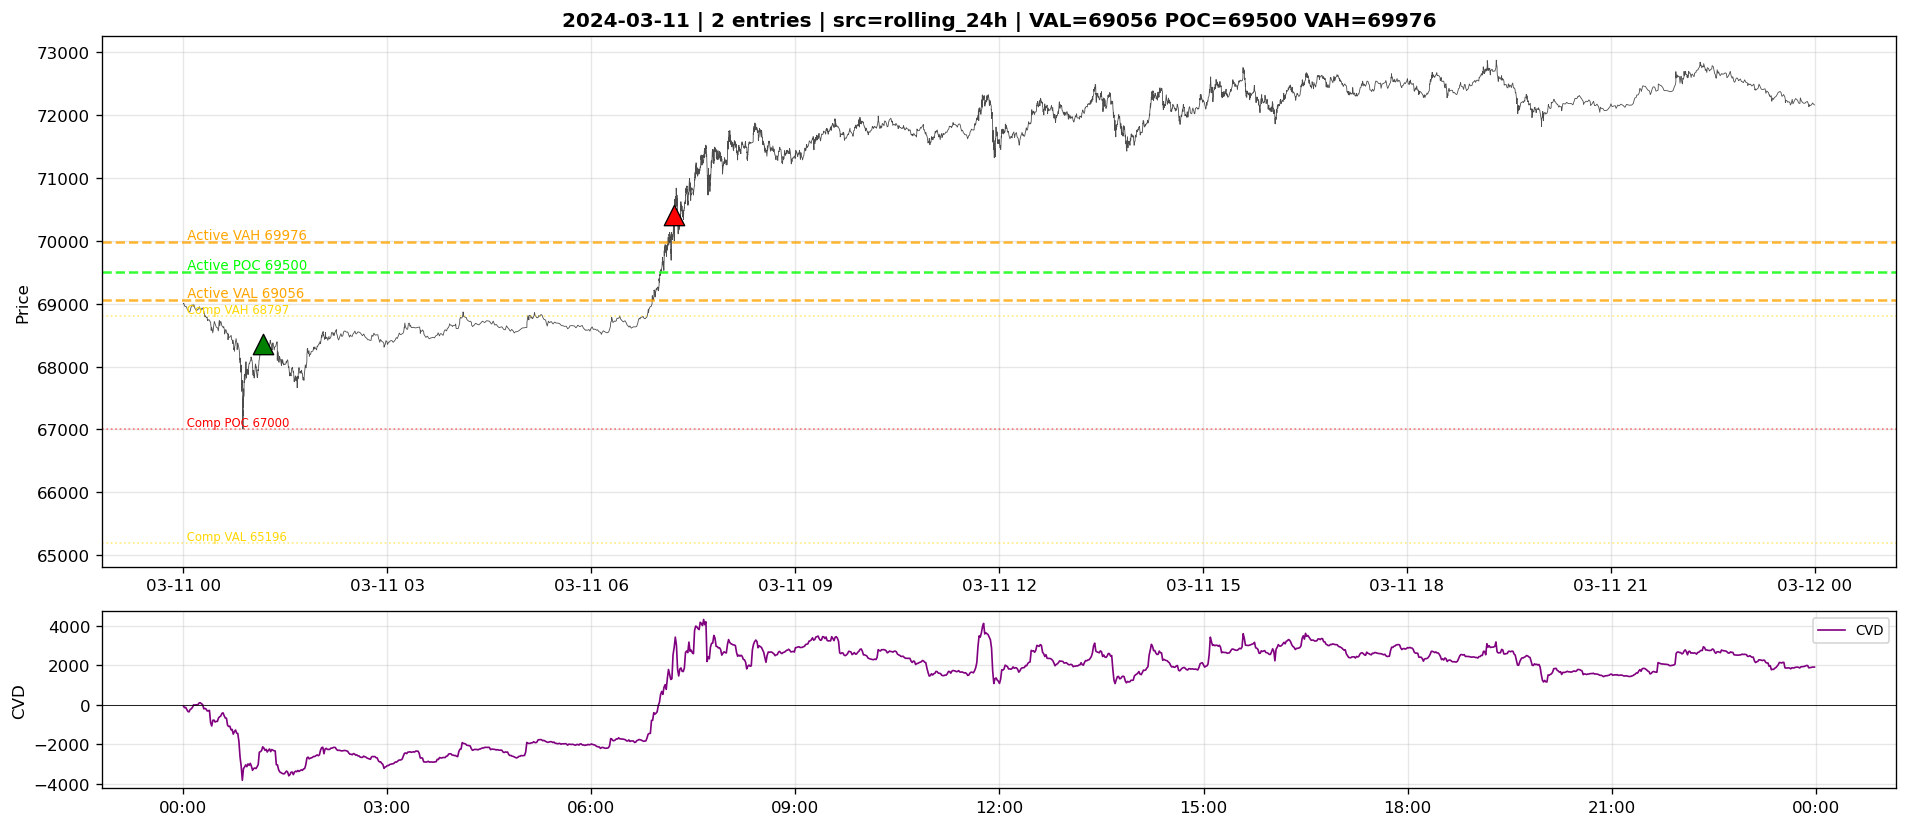

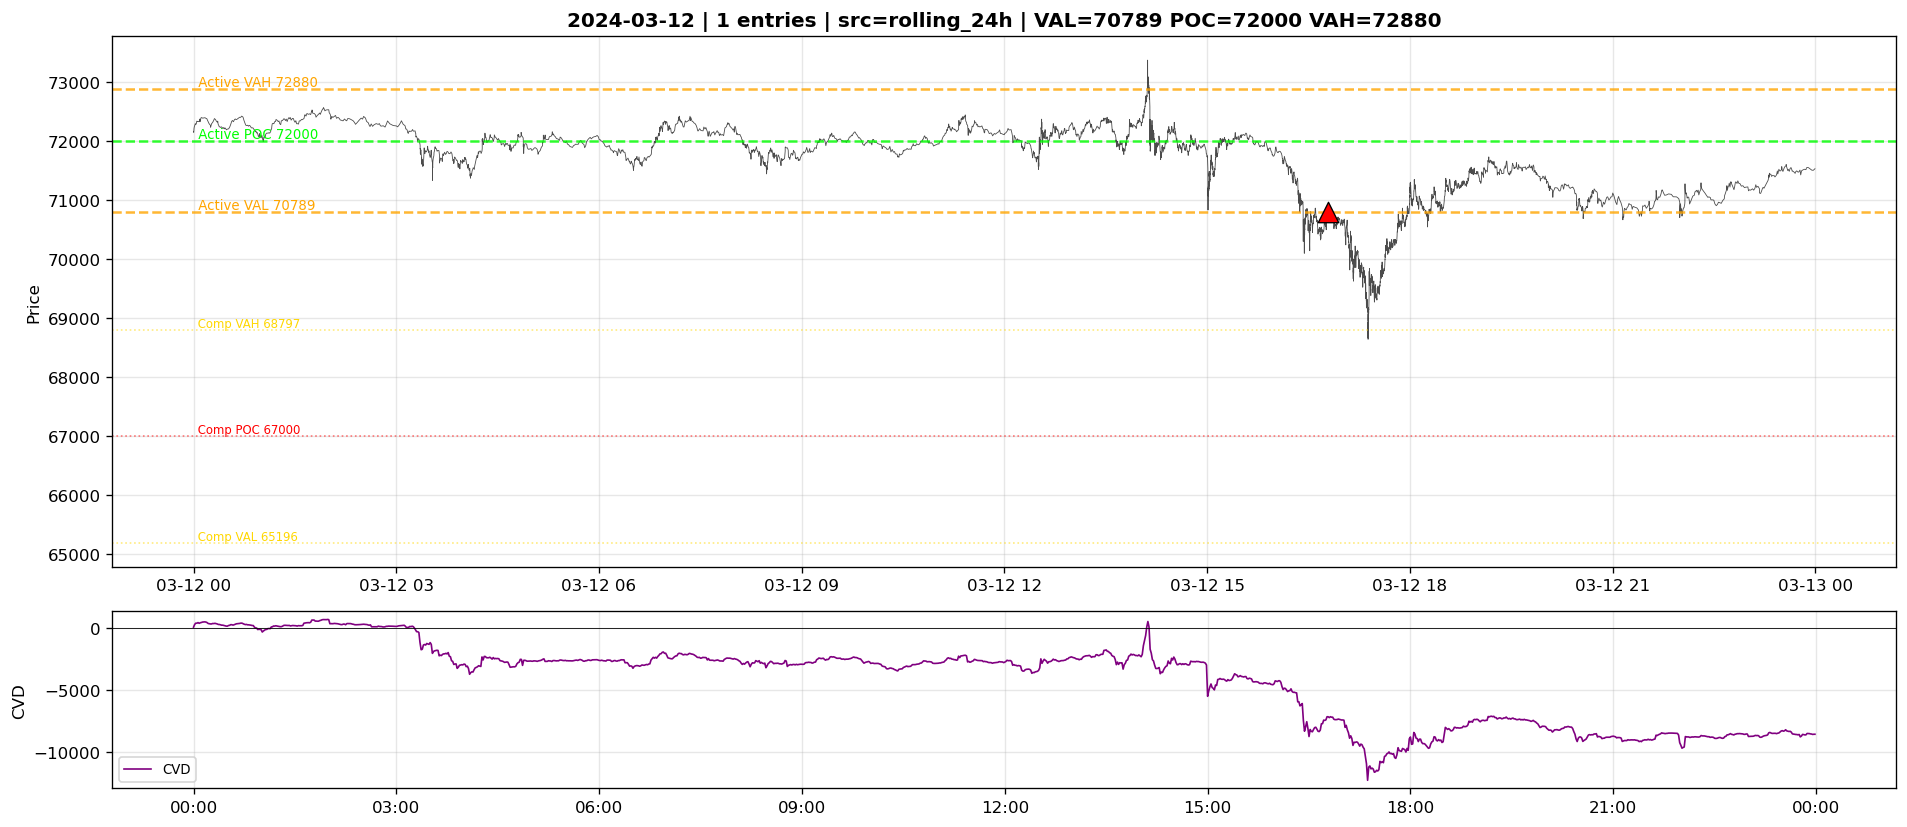

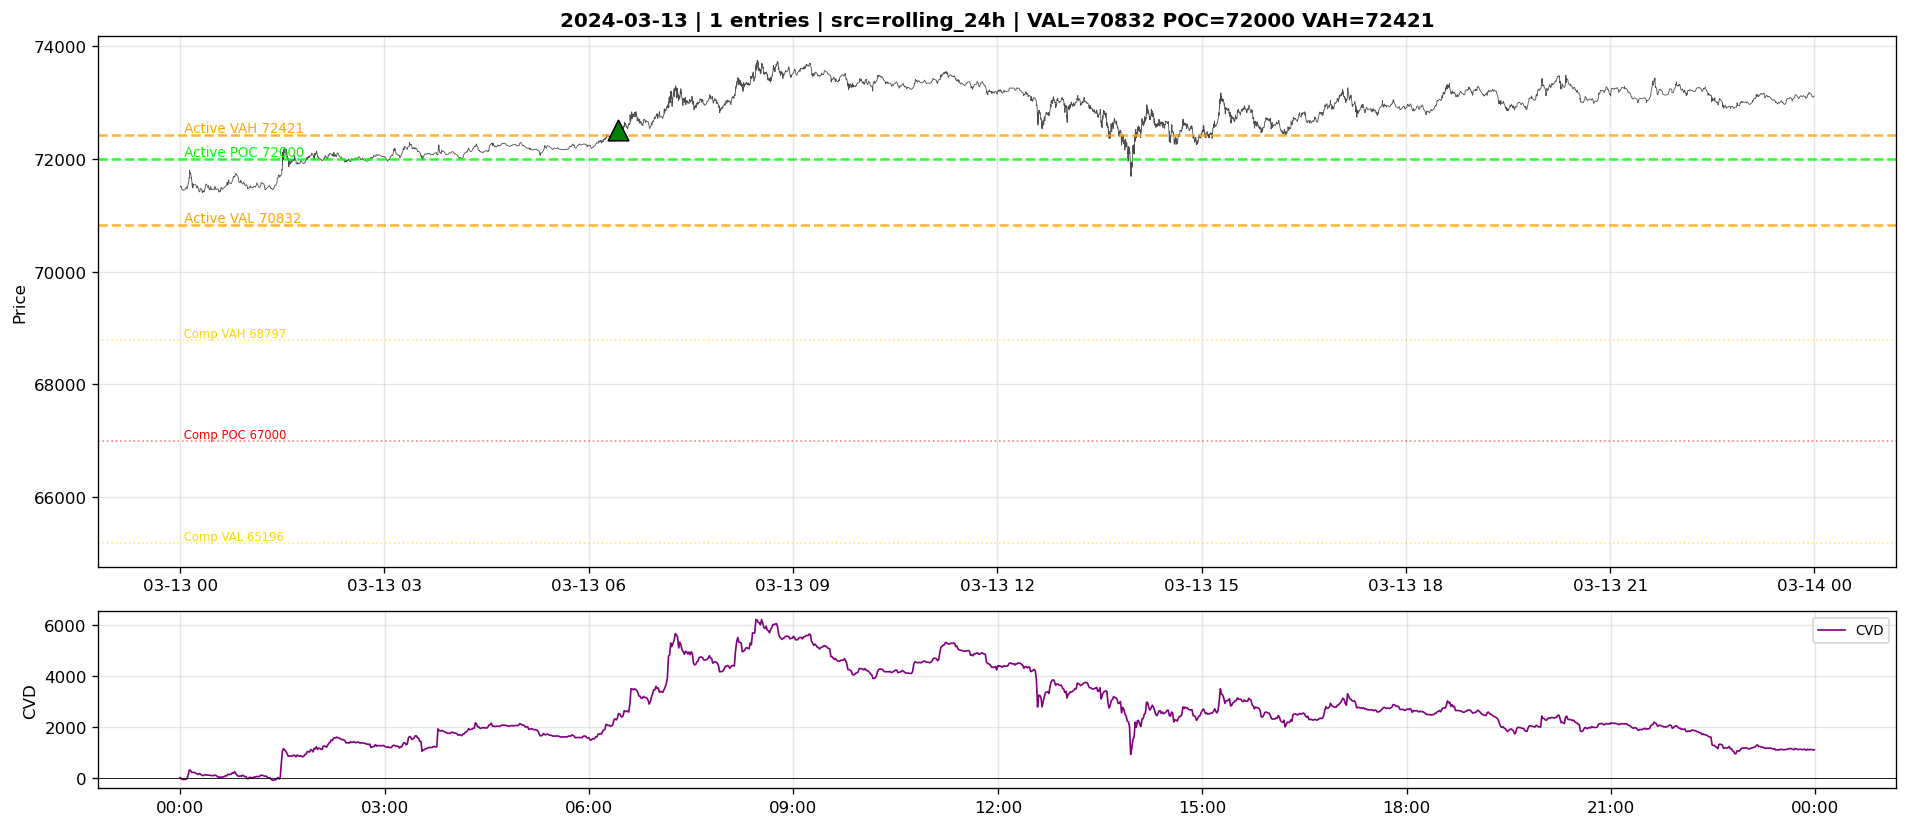

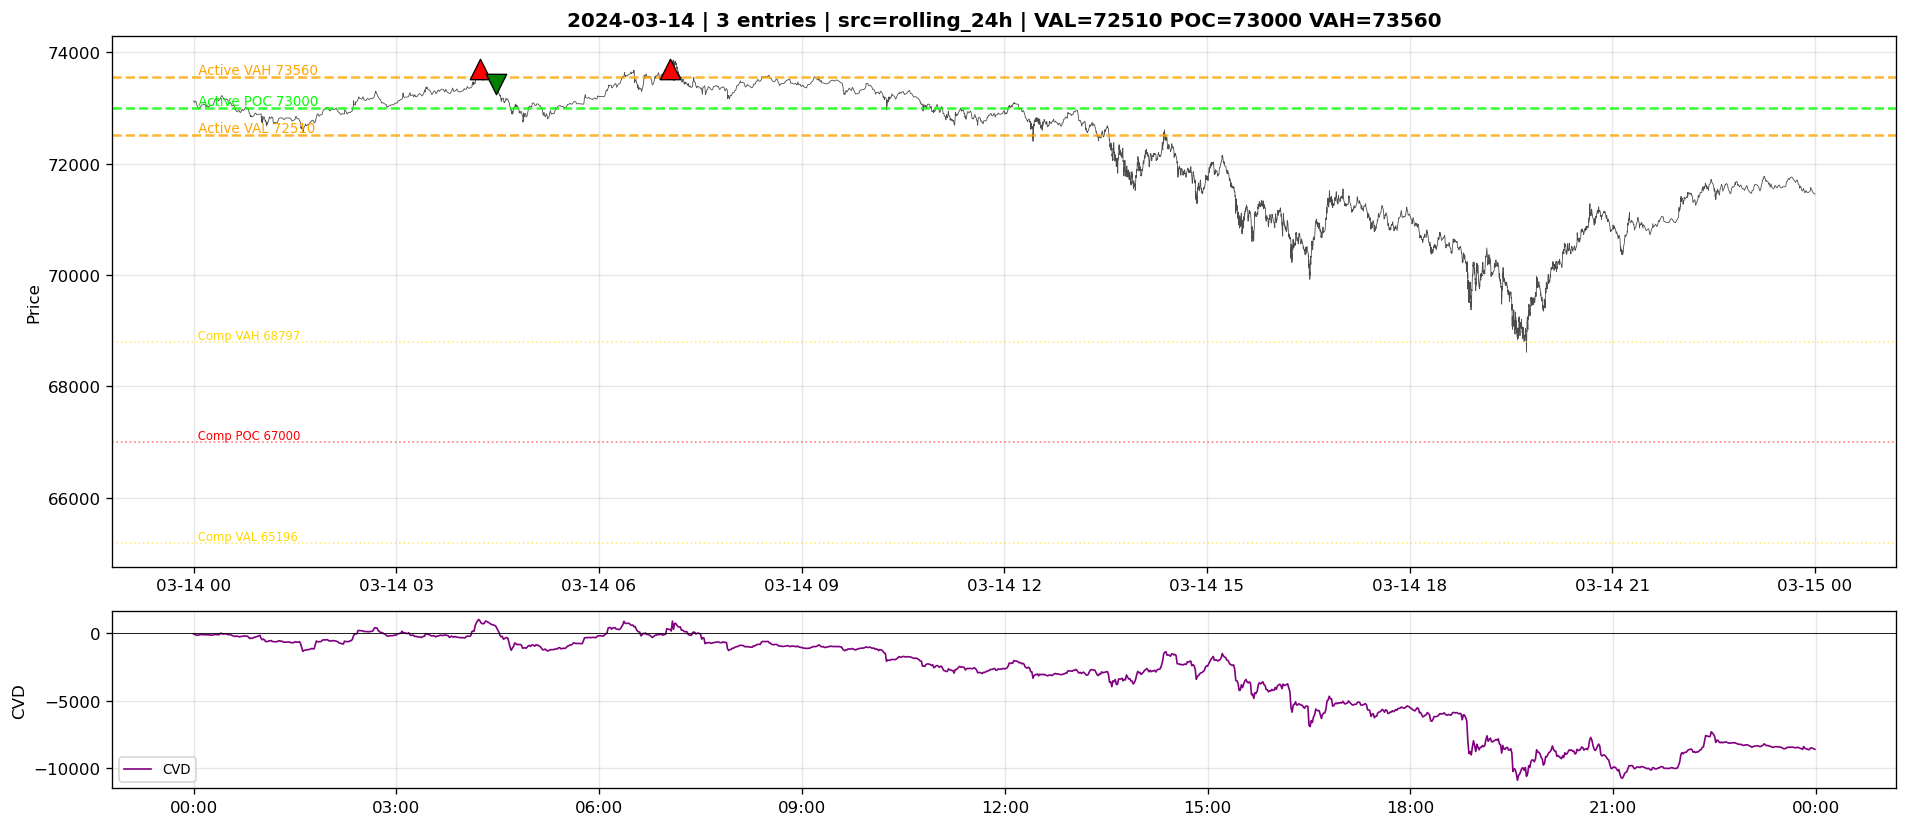

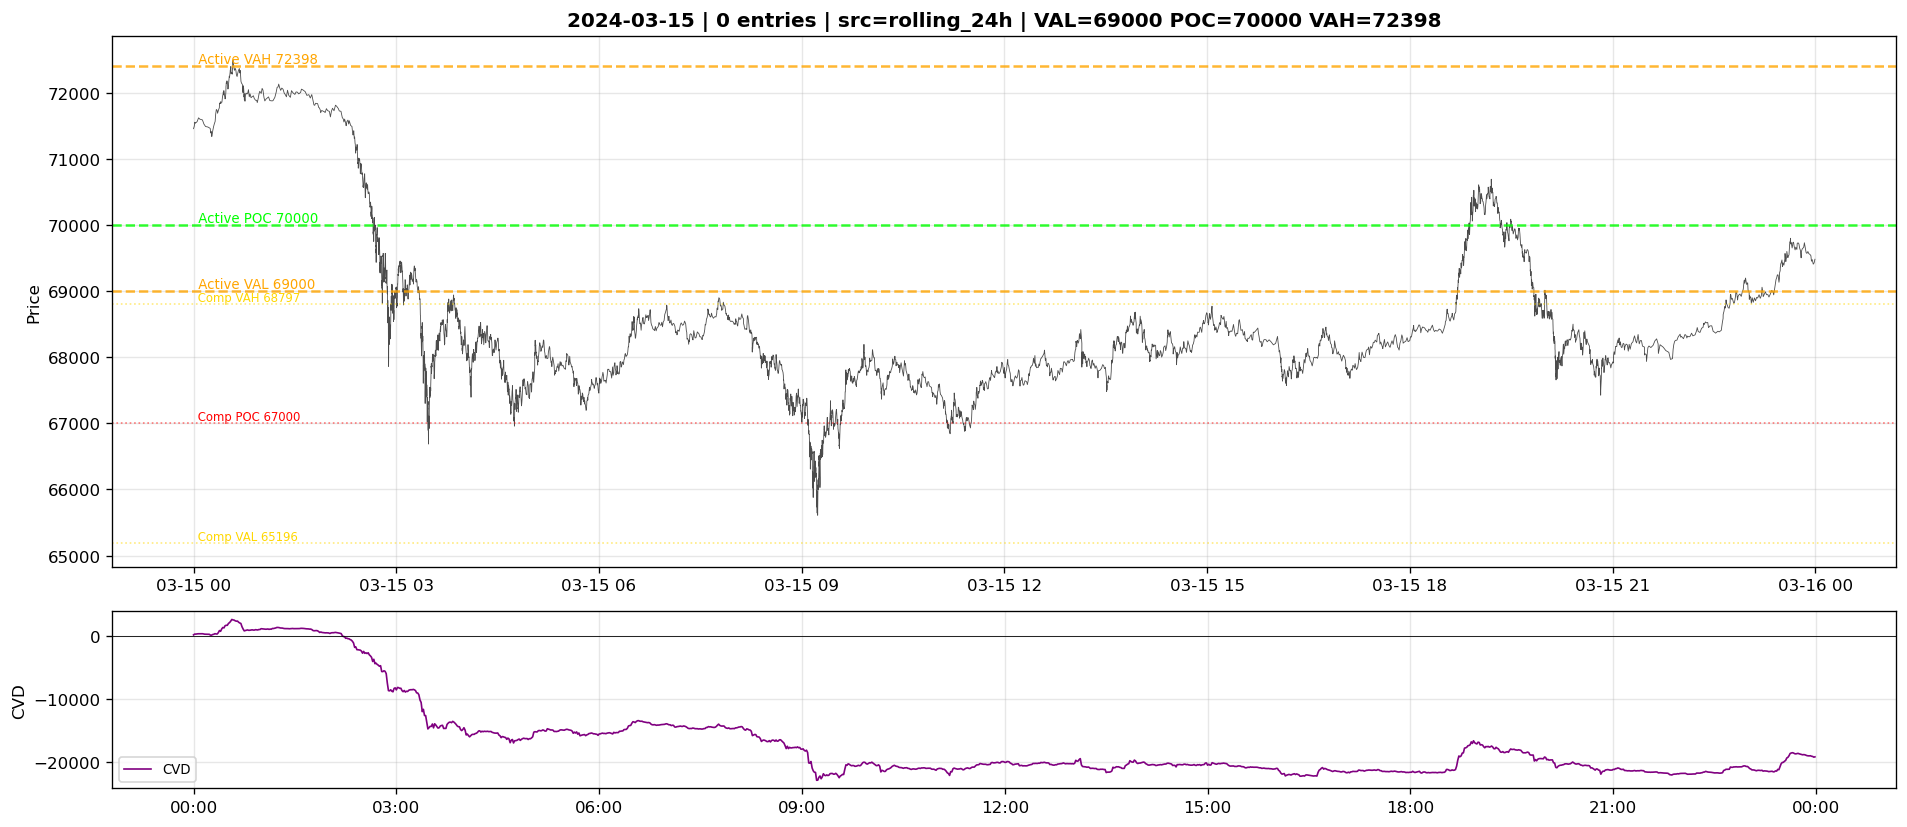

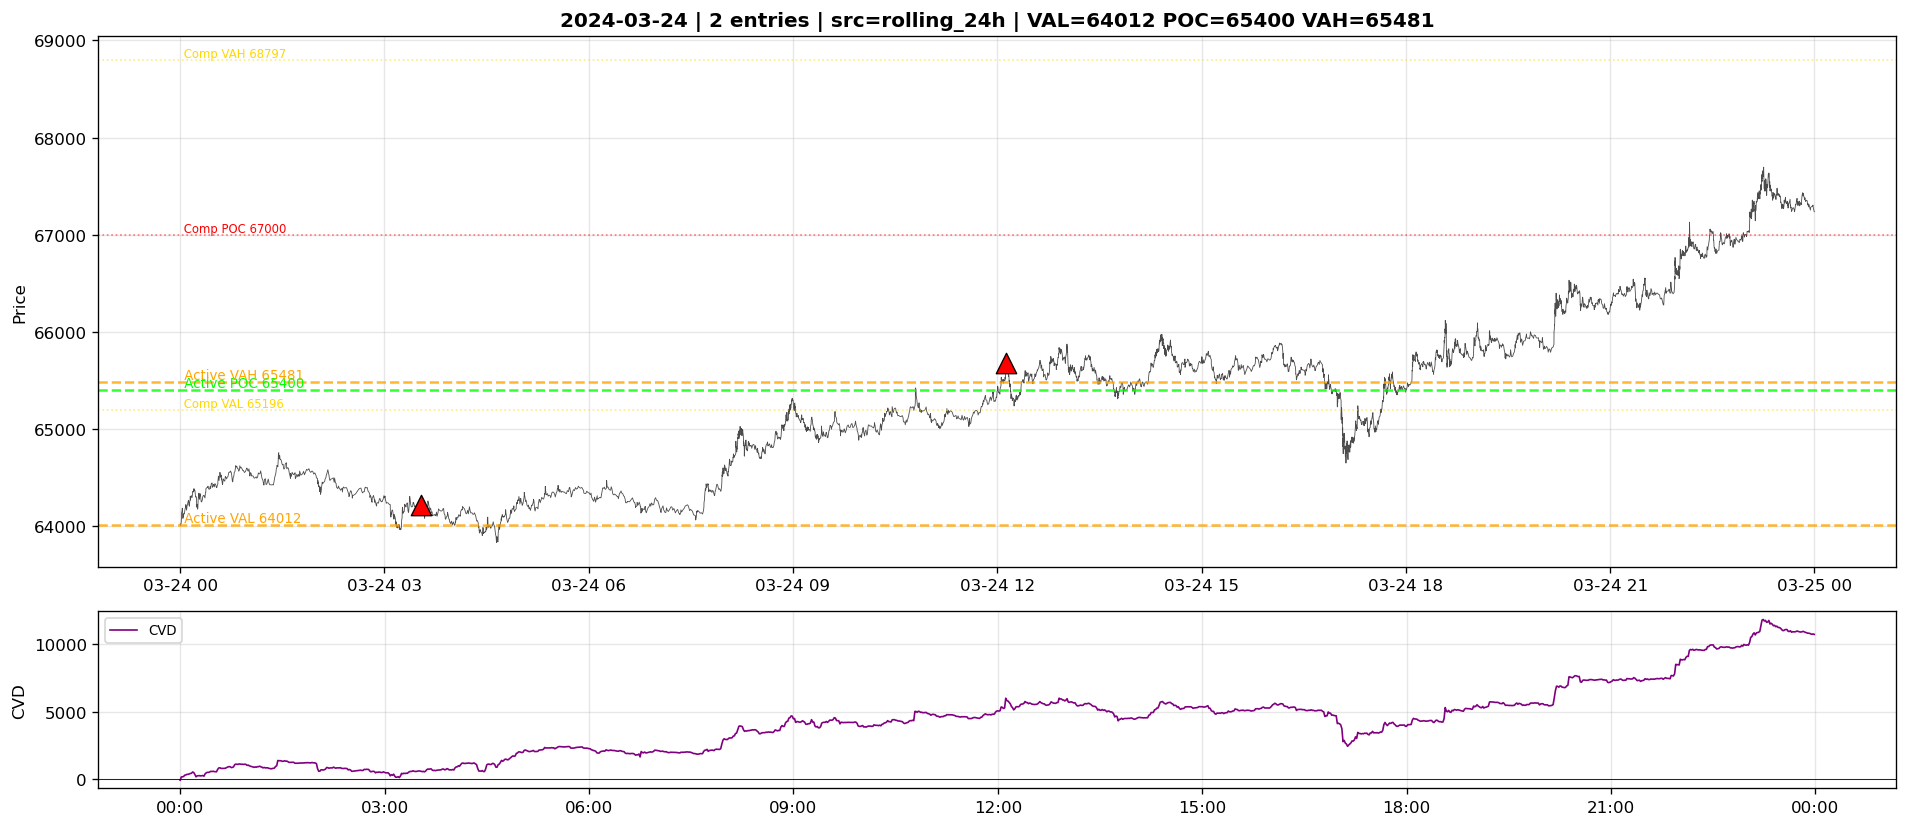

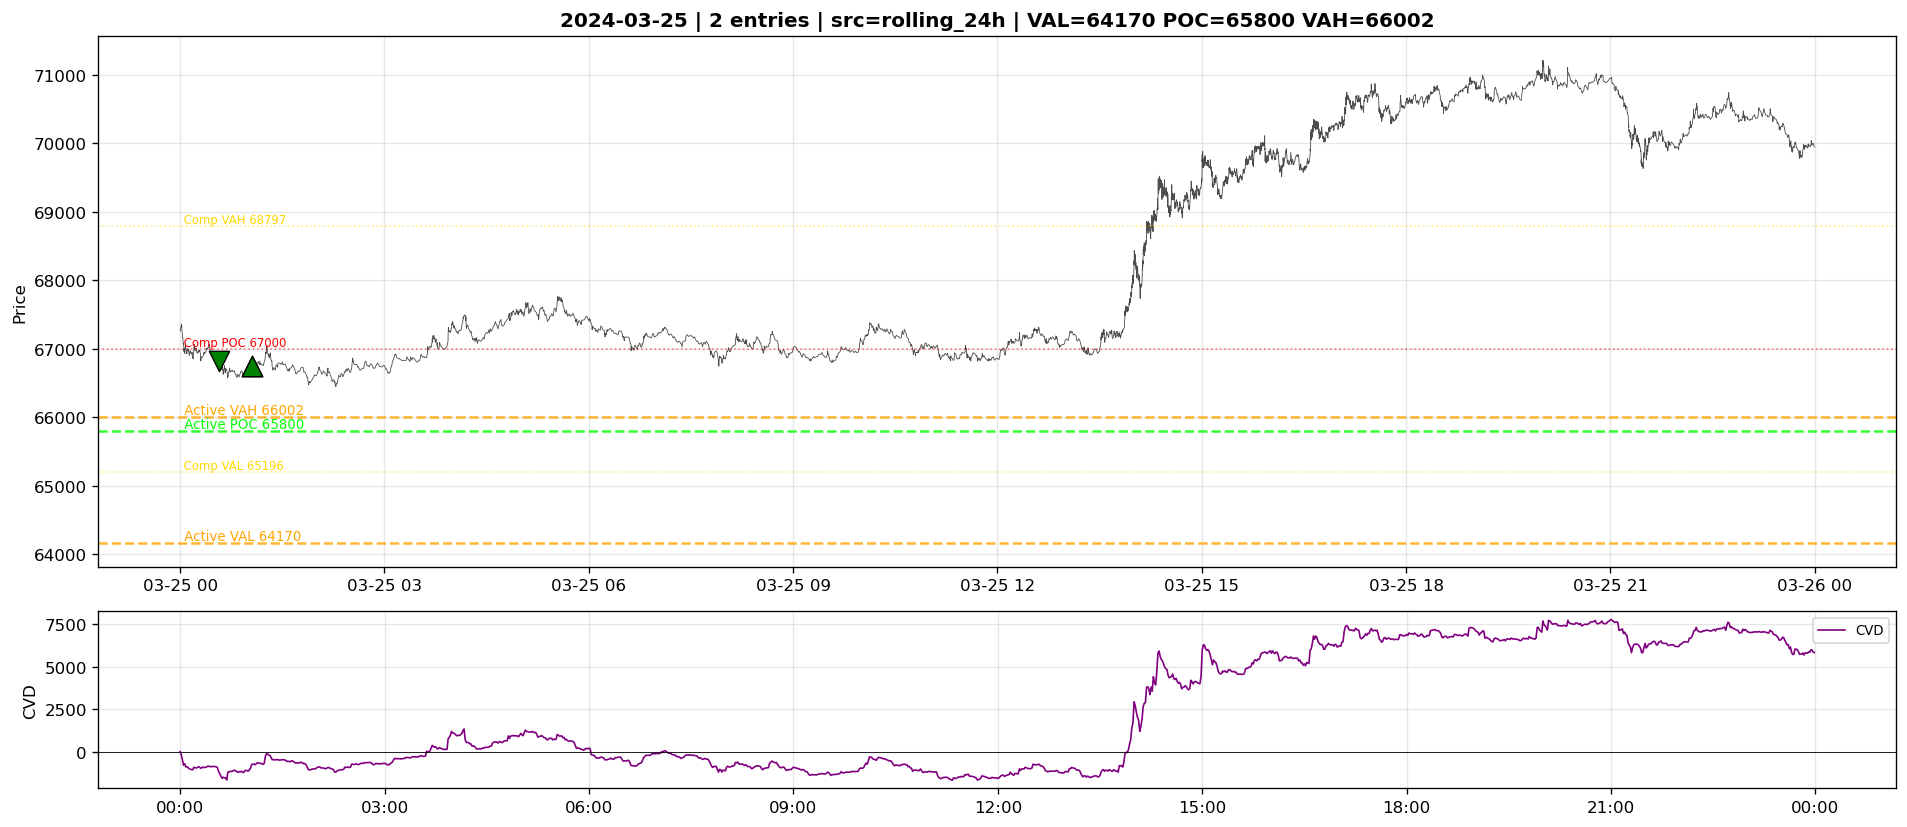

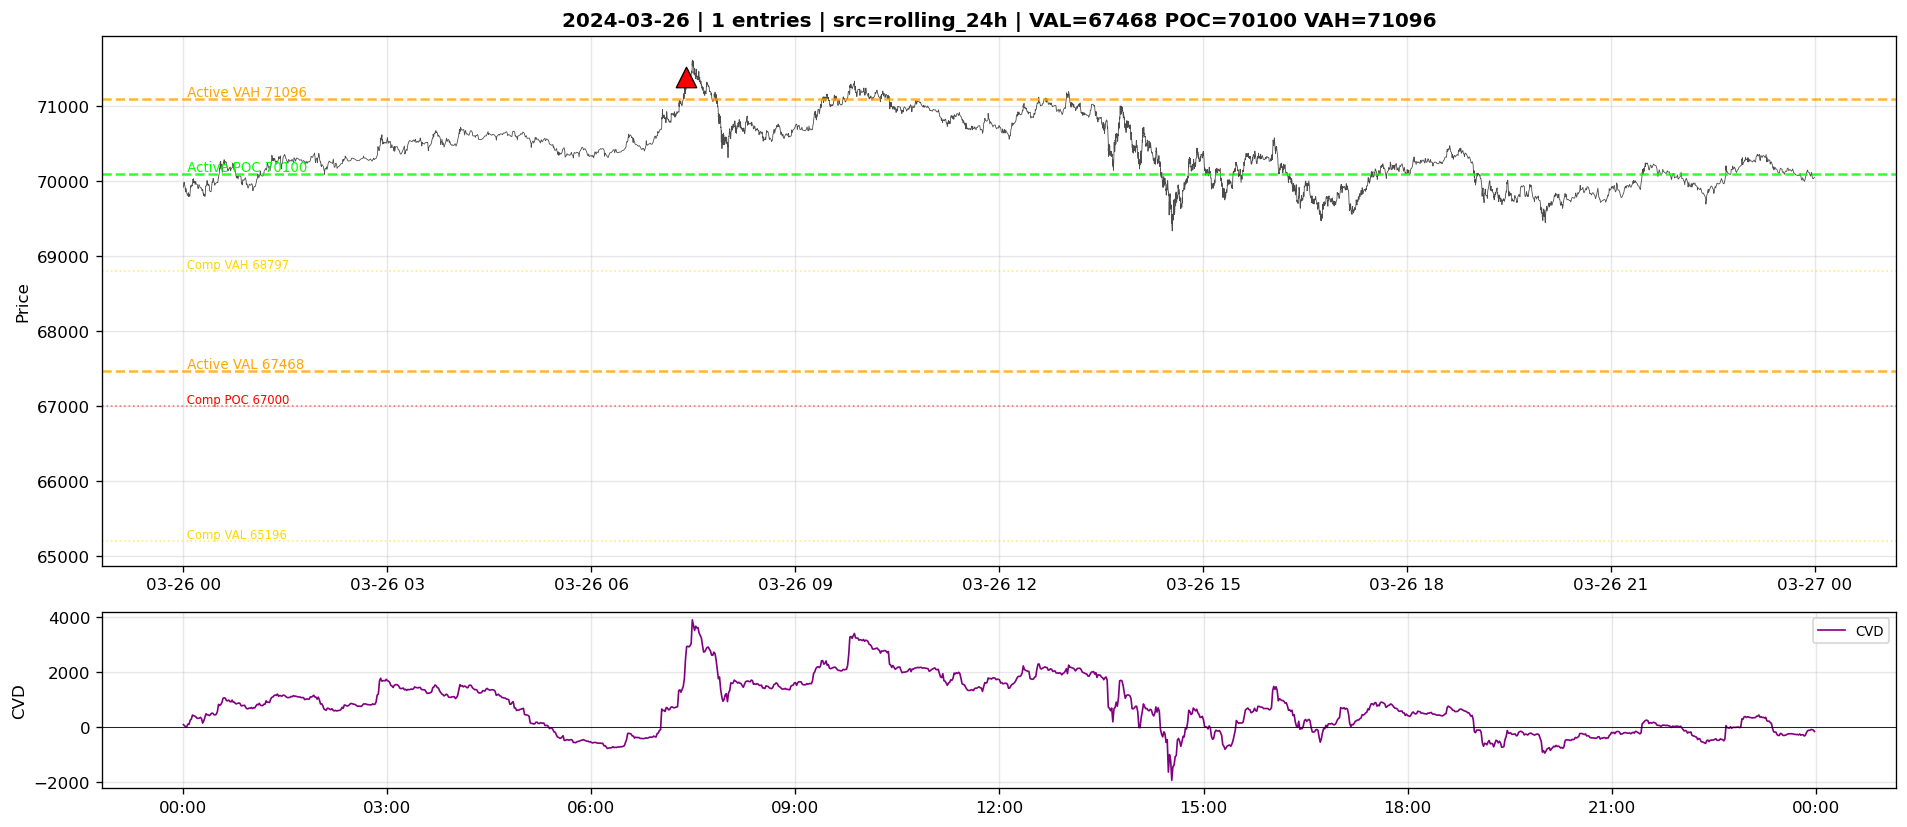

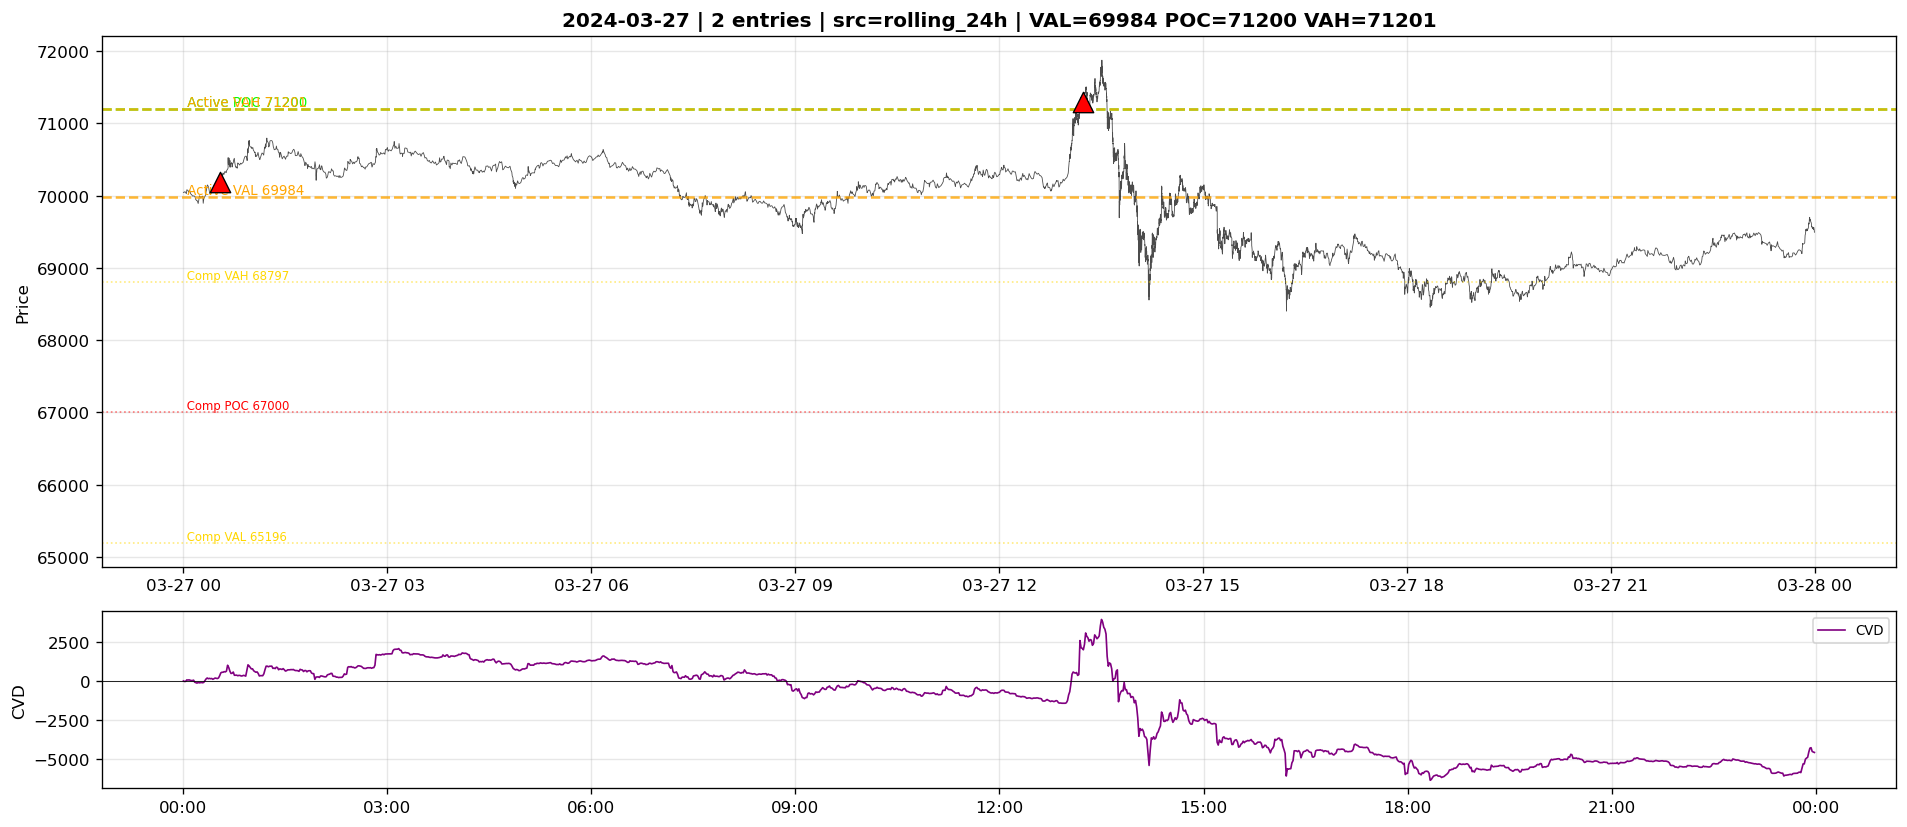

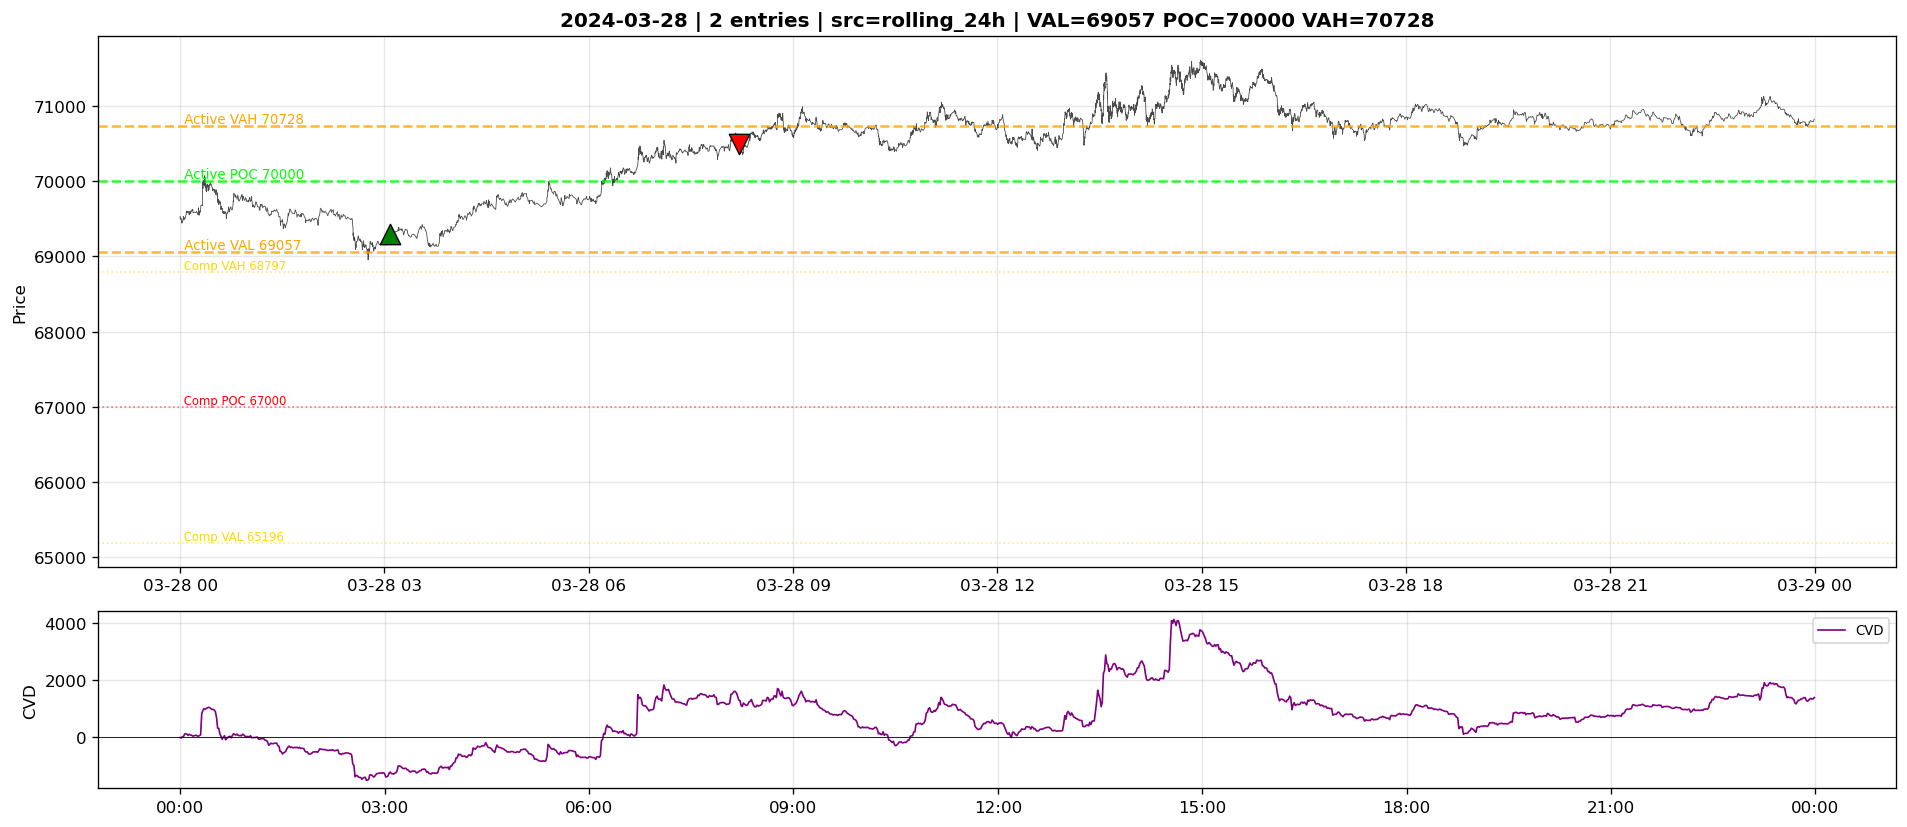

In [9]:
# === Charts (show first and last 5 days only) ===
for d in TEST_DAYS[:5] + TEST_DAYS[-5:]:
    r=results[d]
    tr=r['trades']
    ev=r['events']
    pp=r['prior_prof']
    
    times, prices = [], []
    for e in ev:
        if e['t']=='tr':
            times.append(pd.Timestamp(e['ts'],unit='ms'))
            prices.append(e['p'])
    if not times: continue
    step=max(1,len(times)//5000)
    
    fig,axes=plt.subplots(2,1,figsize=(16,7),gridspec_kw={'height_ratios':[3,1]})
    ax1,ax2=axes
    
    ax1.plot(times[::step],prices[::step],'k-',lw=0.5,alpha=0.7)
    
    for label,px,color in [
        (f'Comp VAL {COMP_VAL:.0f}',COMP_VAL,'gold'),
        (f'Comp POC {COMP_POC:.0f}',COMP_POC,'red'),
        (f'Comp VAH {COMP_VAH:.0f}',COMP_VAH,'gold'),
    ]:
        ax1.axhline(px,color=color,lw=1,ls=':',alpha=0.5)
        ax1.text(times[0],px,f' {label}',fontsize=7,color=color,va='bottom')
    
    strat_obj=results[d].get('strat',None)
    a_val=strat_obj.active_VAL if strat_obj else pp['val']
    a_vah=strat_obj.active_VAH if strat_obj else pp['vah']
    a_poc=strat_obj.active_POC if strat_obj else pp['poc']
    a_src=strat_obj.active_source if strat_obj else '?'
    
    for label,px,color in [
        (f'Active VAL {a_val:.0f}',a_val,'orange'),
        (f'Active POC {a_poc:.0f}',a_poc,'lime'),
        (f'Active VAH {a_vah:.0f}',a_vah,'orange'),
    ]:
        ax1.axhline(px,color=color,lw=1.5,ls='--',alpha=0.8)
        ax1.text(times[0],px,f' {label}',fontsize=8,color=color,va='bottom')
    
    if len(tr)>0:
        for _,r2 in tr.iterrows():
            t_entry=pd.Timestamp(r2['ts_entry'],unit='ms') if r2['ts_entry'] else times[len(times)//2]
            col='green' if r2.get('pnl_usd',0)>0 else 'red'
            mk='^' if r2['side']=='LONG' else 'v'
            ax1.scatter(t_entry,r2['entry'],marker=mk,color=col,s=150,
                       zorder=5,edgecolors='black',linewidth=0.8)
    
    ax1.set_title(f'{d} | {tr["entry"].nunique() if len(tr)>0 else 0} entries | src={a_src} | '
                  f'VAL={a_val:.0f} POC={a_poc:.0f} VAH={a_vah:.0f}',
                  fontweight='bold')
    ax1.set_ylabel('Price'); ax1.grid(alpha=0.3)
    
    mdeltas={}
    for e in ev:
        if e['t']=='tr':
            m=e['ts']//60_000
            mdeltas[m]=mdeltas.get(m,0)+(-e['q'] if e['b'] else e['q'])
    if mdeltas:
        mt=sorted(mdeltas.keys()); mv=[mdeltas[m] for m in mt]
        ml=[pd.Timestamp(m*60_000,unit='ms') for m in mt]
        cvd_line=np.cumsum(mv)
        ax2.plot(ml,cvd_line,color='purple',lw=1,label='CVD')
        ax2.axhline(0,color='black',lw=0.5)
        ax2.set_ylabel('CVD'); ax2.grid(alpha=0.3); ax2.legend(fontsize=8)
    
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.tight_layout(); plt.show()

---
## v12 Changes

- **Extended test window**: from 10 days (Mar 11-22) to 22 days (Mar 11 - Apr 4)
- **Fixed VAH_RECLAIM_LONG overextension**: replaced with breakout-specific late-entry filter — blocks only if close > VAH+2.5×ATR AND close > day_open×1.025 AND 5-bar slope flattening/negative
- **Fixed target_ok for breakouts**: `min_mult=1.0` so mechanically-defined +1R target always passes
- **New `_breakout_slope_flattening()`**: checks if latest 5-bar linear regression slope is ≤ 0 or near-zero
- Preserves all v11 improvements: disabled VAL_RETEST, relaxed CVD logic, day 1 fallback, candidate diagnostics